# OLA Ride Analytics & Booking Status Prediction

## 1. Project Overview

This project analyzes **150,000 OLA ride-booking records** to understand booking outcomes and identify the factors associated with successful and unsuccessful rides.

The dataset contains five booking outcomes:

* Completed
* Cancelled by Driver
* Cancelled by Customer
* No Driver Found
* Incomplete

The project combines **data cleaning, exploratory data analysis (EDA), feature engineering, data leakage analysis, machine learning, model evaluation, and business insights**.

A machine-learning classification approach is used to predict the **Booking Status** of a ride at an operational/dispatch stage.

### Key Technologies

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* XGBoost
* Jupyter Notebook

### Machine Learning Approach

Multiple classification models were evaluated, including:

* Random Forest
* Balanced Random Forest
* SGD Logistic Regression
* XGBoost

The **Balanced Random Forest** was selected as the final model because it provided better minority-class detection and achieved a **Macro F1-score of 0.51**, compared with the baseline Random Forest Macro F1-score of 0.46.

### Important Modeling Consideration

The feature **Average VTAT (Vehicle Time to Arrival)** and its missingness contain strong operational information about booking outcomes. Since VTAT is associated with the driver-dispatch stage, the final model should be interpreted as an **operational/dispatch-stage prediction model**, rather than a pure prediction made immediately at the time of booking.

### Project Outcome

The project aims to demonstrate how ride-booking data can be transformed into actionable insights and a machine-learning solution that can help identify patterns associated with cancellations, incomplete rides, driver availability, and completed bookings.


# 2. Business Problem & Objectives

## Business Problem

Ride-hailing platforms such as OLA handle a large number of bookings every day. However, not every booking results in a completed ride.

Bookings may be:

* Cancelled by the customer
* Cancelled by the driver
* Unfulfilled because no driver is found
* Marked as incomplete
* Successfully completed

A high number of unsuccessful bookings can affect **customer experience, driver utilization, operational efficiency, and overall service quality**.

The objective of this project is to analyze historical ride-booking data to understand the major patterns associated with different booking outcomes and develop a machine-learning model that can classify the likely booking status at an operational/dispatch stage.

## Project Objectives

### 1. Analyze Booking Performance

Understand the overall distribution of completed, cancelled, incomplete, and unfulfilled bookings.

### 2. Identify Cancellation Patterns

Analyze customer and driver cancellation reasons to identify common operational issues.

### 3. Analyze Ride Behavior

Study booking patterns across:

* Vehicle types
* Time of day
* Day of week
* Weekdays vs weekends
* Pickup locations
* Drop locations
* Ride distance
* Booking value
* Driver and customer ratings

### 4. Engineer Useful Features

Create additional features such as:

* Year
* Month
* Day
* Hour
* Day of Week
* Weekend Indicator
* Day Period

These features help capture temporal patterns in booking behavior.

### 5. Identify Data Leakage

Evaluate whether certain variables contain information that would only become available after the booking outcome or during the dispatch process.

Features such as cancellation reasons, booking value, ride distance, payment method, and CTAT are reviewed carefully before being considered for machine learning.

### 6. Build Machine Learning Models

Develop and compare multiple classification models for predicting `Booking Status`.

### 7. Handle Class Imbalance

Since completed rides represent the majority of observations, class imbalance is addressed using appropriate evaluation metrics and class-weighted modeling techniques.

### 8. Evaluate Model Performance

Compare models using:

* Accuracy
* Macro F1-score
* Balanced Accuracy
* Precision
* Recall
* Confusion Matrix

### 9. Generate Business Insights

Translate the analysis and model results into practical insights that can help improve ride completion, reduce cancellations, and identify operational challenges.


# 3. Dataset Overview

## Dataset Description

The dataset contains **150,000 OLA ride-booking records** representing individual ride-booking transactions.

Each record contains information about the booking, customer, vehicle, locations, timing, ride characteristics, payment details, ratings, and booking outcome.

## Dataset Dimensions

* **Total Records:** 150,000
* **Initial Features:** 21
* **Features after Feature Engineering:** 28
* **Target Variable:** `Booking Status`
* **Target Classes:** 5

## Booking Status Categories

| Booking Status        | Description                                |
| --------------------- | ------------------------------------------ |
| Completed             | Ride was successfully completed            |
| Cancelled by Driver   | Driver cancelled the booking               |
| Cancelled by Customer | Customer cancelled the booking             |
| No Driver Found       | No driver was available for the booking    |
| Incomplete            | Booking did not result in a completed ride |

## Major Data Categories

### Booking Information

* Booking ID
* Booking Status
* Customer ID

### Ride Information

* Vehicle Type
* Ride Distance
* Booking Value
* Avg VTAT
* Avg CTAT

### Location Information

* Pickup Location
* Drop Location

### Timing Information

* Date
* Time

### Cancellation & Incomplete Ride Information

* Reason for cancelling by Customer
* Driver Cancellation Reason
* Incomplete Rides Reason

### Payment & Rating Information

* Payment Method
* Driver Ratings
* Customer Rating

## Target Variable Distribution

The target variable contains five classes:

* **Completed:** 93,000 records (62%)
* **Cancelled by Driver:** 27,000 records (18%)
* **No Driver Found:** 10,500 records (7%)
* **Cancelled by Customer:** 10,500 records (7%)
* **Incomplete:** 9,000 records (6%)

The distribution shows a clear **class imbalance**, with Completed bookings representing the majority of the dataset. Therefore, model evaluation should not rely on accuracy alone and should also consider metrics such as Macro F1-score and Balanced Accuracy.


# 4. Data Loading

The OLA ride-booking dataset was loaded into a Pandas DataFrame for further analysis and machine learning.

The dataset was imported from a CSV file named `rideBookings.csv`.


In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv('rideBookings.csv')

print("Dataset loaded successfully.")
print("Shape:", data.shape)

Dataset loaded successfully.
Shape: (150000, 21)


# 5. Data Quality & Initial Inspection

Before performing any analysis, the dataset was inspected to understand its structure, data types, missing values, and duplicate records.

The following checks were performed:

* Dataset dimensions
* Column names
* Data types
* Missing values
* Duplicate records
* Initial sample of the dataset


In [2]:
# Dataset shape
print("Dataset Shape:")
print(data.shape)

print("\n" + "="*60)

# Column names
print("Column Names:")
print(data.columns.tolist())

print("\n" + "="*60)

# Data types
print("Data Types:")
print(data.dtypes)

print("\n" + "="*60)

# First 5 rows
print("First 5 Rows:")
display(data.head())

Dataset Shape:
(150000, 21)

Column Names:
['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']

Data Types:
Date                                     str
Time                                     str
Booking ID                               str
Booking Status                           str
Customer ID                              str
Vehicle Type                             str
Pickup Location                          str
Drop Location                            str
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer        str
C

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [3]:
# Missing value analysis
missing_values = data.isna().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print("Missing Values by Column:")
display(missing_values)

Missing Values by Column:


Incomplete Rides                     141000
Incomplete Rides Reason              141000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Driver Ratings                        57000
Customer Rating                       57000
Avg CTAT                              48000
Ride Distance                         48000
Booking Value                         48000
Payment Method                        48000
Avg VTAT                              10500
dtype: int64

In [4]:
# Duplicate record check
duplicate_count = data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# 6. Data Cleaning

Data cleaning was performed to ensure that date and time fields were stored in appropriate formats and could be used reliably for analysis and feature engineering.


In [5]:
# Convert Date column to datetime format

data['Date'] = pd.to_datetime(
    data['Date'],
    errors='coerce'
)

print("Date datatype:", data['Date'].dtype)
print("Missing Date values:", data['Date'].isna().sum())

Date datatype: datetime64[us]
Missing Date values: 0


In [6]:
# Convert Time column to datetime.time format

data['Time'] = pd.to_datetime(
    data['Time'],
    format='%H:%M:%S',
    errors='coerce'
).dt.time

print("Time datatype:", data['Time'].dtype)
print("Missing Time values:", data['Time'].isna().sum())

Time datatype: object
Missing Time values: 0


In [7]:
# Verify cleaned Date and Time columns

display(
    data[['Date', 'Time']].head(10)
)

print("Date missing values:", data['Date'].isna().sum())
print("Time missing values:", data['Time'].isna().sum())

,Date,Time
0,2024-03-23,12:29:38
1,2024-11-29,18:01:39
2,2024-08-23,08:56:10
3,2024-10-21,17:17:25
4,2024-09-16,22:08:00
5,2024-02-06,09:44:56
6,2024-06-17,15:45:58
7,2024-03-19,17:37:37
8,2024-09-14,12:49:09
9,2024-12-16,19:06:48


Date missing values: 0
Time missing values: 0


# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand booking patterns, ride outcomes, customer and driver behavior, operational issues, and temporal trends within the OLA dataset.

The analysis covers booking status, vehicle type, time-based patterns, cancellation reasons, ride characteristics, ratings, payment methods, and geographical patterns.

The objective of EDA is to identify important business patterns before applying machine learning.


## 7.1 Booking Status Distribution

The distribution of booking statuses was analyzed to understand the overall outcome of ride bookings and identify whether the dataset contains class imbalance.

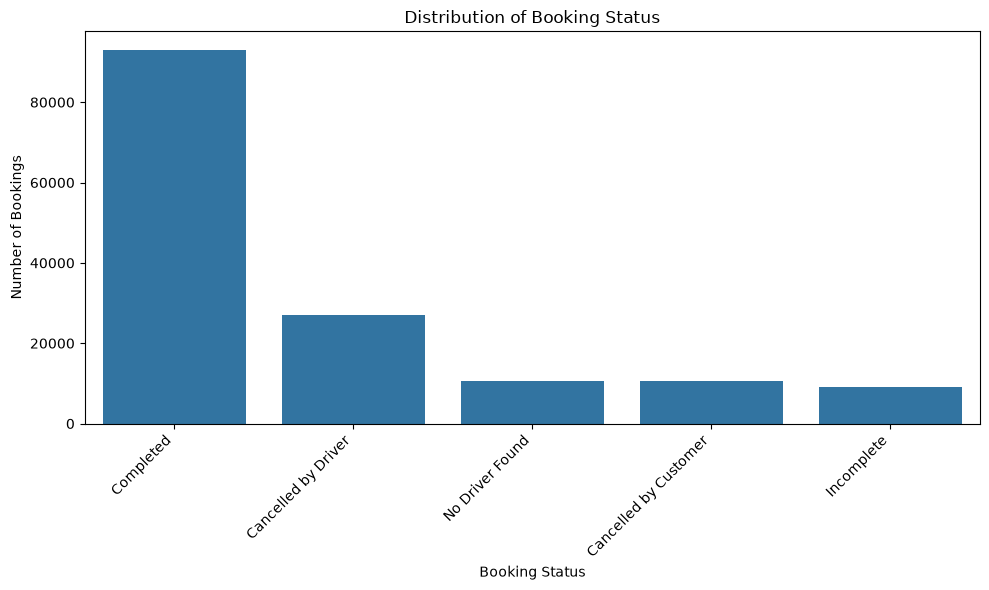

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.countplot(
    data=data,
    x='Booking Status',
    order=data['Booking Status'].value_counts().index
)

plt.title('Distribution of Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Booking Status Percentage Distribution

Percentage distribution was calculated to understand the relative contribution of each booking outcome.

In [9]:
booking_status_percentage = (
    data['Booking Status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Booking Status Percentage Distribution:")
display(booking_status_percentage)

Booking Status Percentage Distribution:


Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64

### Key Observation

Completed rides represent **62%** of all bookings, while the remaining **38%** consist of driver cancellations, customer cancellations, incomplete rides, and bookings where no driver was found.

This indicates a clear class imbalance in the target variable, which is important to consider during machine-learning model development and evaluation.

## 7.2 Booking Status by Vehicle Type

The relationship between vehicle type and booking status was analyzed to understand whether different vehicle categories show different booking outcomes.

In [10]:
vehicle_status_pct = pd.crosstab(
    data['Vehicle Type'],
    data['Booking Status'],
    normalize='index'
).mul(100).round(2)

print("Booking Status Distribution by Vehicle Type (%):")
display(vehicle_status_pct)

Booking Status Distribution by Vehicle Type (%):


Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Vehicle Type,,,,,
Auto,7.16,17.75,61.88,6.04,7.16
Bike,6.99,18.11,62.33,5.90,6.67
Go Mini,7.04,17.88,62.23,6.09,6.76
Go Sedan,6.75,18.54,61.44,6.05,7.22
Premier Sedan,6.99,17.94,62.13,5.87,7.07
Uber XL,7.35,17.13,62.55,5.89,7.08
eBike,6.85,18.06,62.05,5.97,7.07


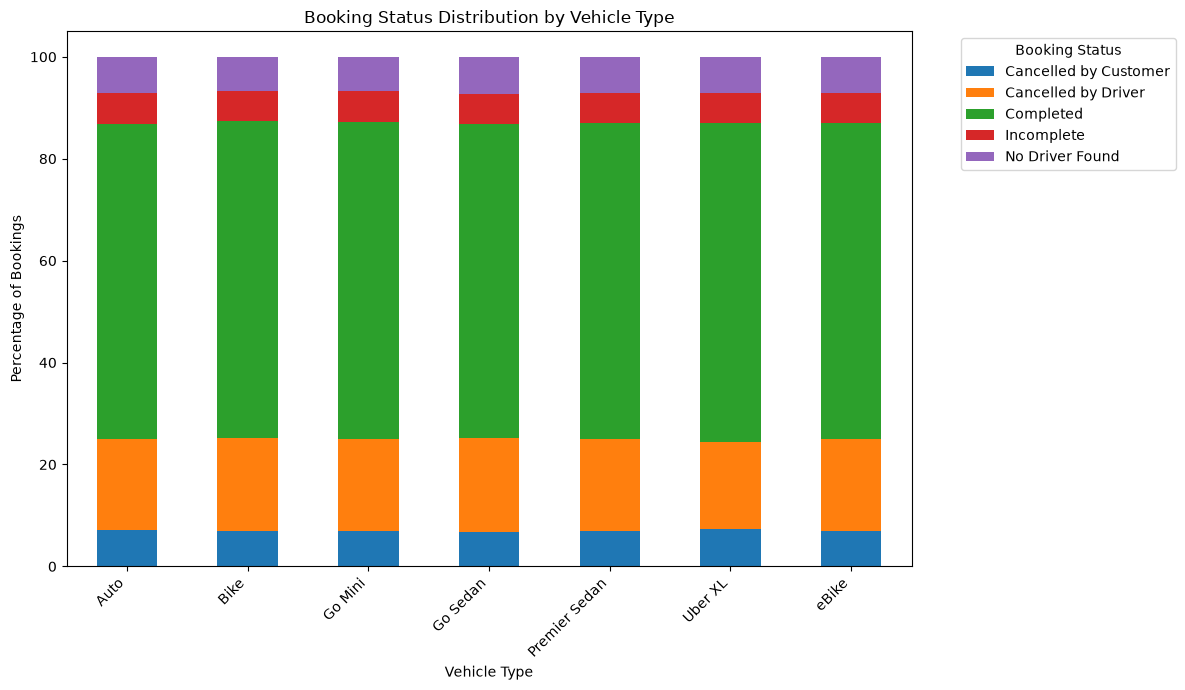

In [11]:
vehicle_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)

plt.title('Booking Status Distribution by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Percentage of Bookings')
plt.xticks(rotation=45, ha='right')
plt.legend(
    title='Booking Status',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

### Key Observation

The booking outcome distribution is relatively similar across vehicle types.

* **Uber XL** has the highest completion rate at **62.55%**.
* **Go Sedan** has the lowest completion rate at **61.44%**.
* **Go Sedan** has the highest driver cancellation rate at **18.54%**.
* **Uber XL** has the lowest driver cancellation rate at **17.13%**.
* **Go Sedan** also has the highest `No Driver Found` rate at **7.22%**.
* Overall, the differences between vehicle categories are relatively small, suggesting that vehicle type alone may not explain booking outcomes.

These patterns will be further evaluated during machine-learning modeling.


## 7.3 Booking Status by Day Period

The relationship between time of day and booking status was analyzed to identify whether booking outcomes vary across different periods of the day.

In [14]:
day_period_status_pct = pd.crosstab(
    data['Day_Period'],
    data['Booking Status'],
    normalize='index'
).mul(100).round(2)

print("Booking Status Distribution by Day Period (%):")
display(day_period_status_pct)

Booking Status Distribution by Day Period (%):


Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Day_Period,,,,,
Afternoon,7.10,18.12,61.73,6.06,6.99
Evening,7.00,18.12,61.83,6.06,6.98
Morning,6.96,17.88,62.16,5.97,7.03
Night,6.91,17.83,62.43,5.84,6.99


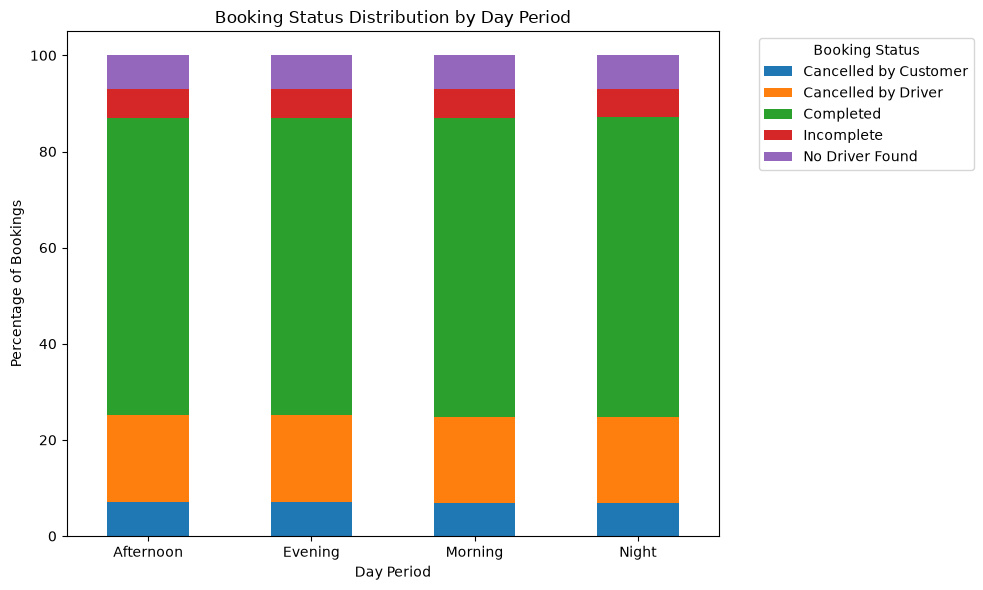

In [15]:
day_period_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Booking Status Distribution by Day Period')
plt.xlabel('Day Period')
plt.ylabel('Percentage of Bookings')
plt.xticks(rotation=0)
plt.legend(
    title='Booking Status',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

### Key Observation

The booking outcome distribution is relatively consistent across different periods of the day.

* **Night** has the highest completion rate at **62.43%**.
* **Afternoon** has the lowest completion rate at **61.73%**.
* **Afternoon and Evening** have the highest driver cancellation rate at **18.12%**.
* **Night** has the lowest driver cancellation rate at **17.83%**.
* The `No Driver Found` rate remains close to **7%** across all day periods.

Overall, the differences across day periods are relatively small, suggesting that **time of day alone is not a strong differentiating factor for booking outcomes**.


## 7.4 Booking Status by Day of Week

The relationship between the day of the week and booking status was analyzed to identify whether ride outcomes vary across different days.

In [16]:
day_status_pct = pd.crosstab(
    data['Day_of_Week'],
    data['Booking Status'],
    normalize='index'
).mul(100).round(2)

# Arrange days in calendar order
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_status_pct = day_status_pct.reindex(day_order)

print("Booking Status Distribution by Day of Week (%):")
display(day_status_pct)

Booking Status Distribution by Day of Week (%):


Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Day_of_Week,,,,,
Monday,6.98,18.67,61.53,6.03,6.79
Tuesday,6.87,18.32,61.57,6.23,7.01
Wednesday,7.07,17.76,62.09,5.92,7.17
Thursday,6.97,17.69,62.25,6.10,6.99
Friday,7.32,17.65,61.94,5.88,7.21
Saturday,6.75,17.98,62.40,5.97,6.89
Sunday,7.05,17.92,62.22,5.87,6.94


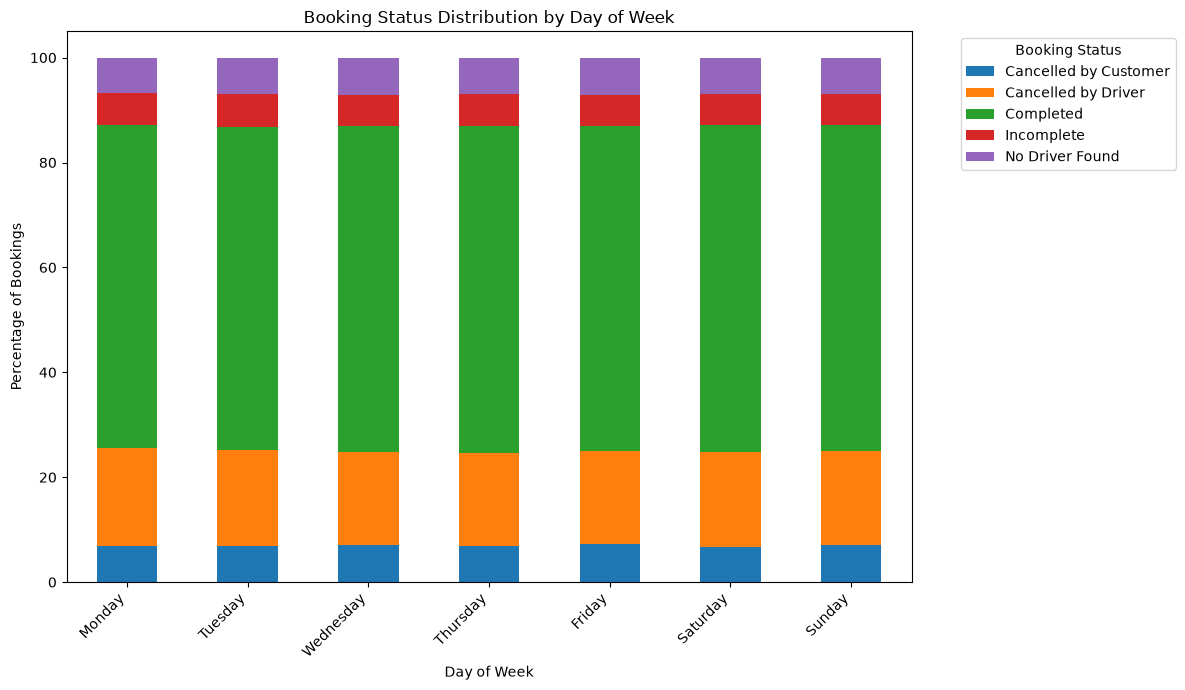

In [17]:
day_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)

plt.title('Booking Status Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Percentage of Bookings')
plt.xticks(rotation=45, ha='right')
plt.legend(
    title='Booking Status',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

### Key Observation

- Booking outcomes remain relatively consistent across all days of the week.
- **Saturday** has the highest completion rate at **62.40%**, while **Monday** has the lowest at **61.53%**.
- **Monday** has the highest driver cancellation rate at **18.67%**, while **Friday** has the lowest at **17.65%**.
- **Friday** has the highest customer cancellation rate at **7.32%**, while **Saturday** has the lowest at **6.75%**.
- The **No Driver Found** rate remains close to 7% across all days, ranging from **6.79% to 7.21%**.
- Overall, the differences across weekdays are relatively small, suggesting that **day of week alone is not a major determinant of booking outcomes**.

## 7.5 Booking Status: Weekday vs Weekend

The relationship between weekday and weekend bookings was analyzed to determine whether booking outcomes differ between regular working days and weekends.

In [18]:
weekday_weekend_status_pct = pd.crosstab(
    data['Is_Weekend'],
    data['Booking Status'],
    normalize='index'
).mul(100).round(2)

weekday_weekend_status_pct.index = (
    weekday_weekend_status_pct.index
    .map({0: 'Weekday', 1: 'Weekend'})
)

print("Booking Status Distribution: Weekday vs Weekend (%):")
display(weekday_weekend_status_pct)

Booking Status Distribution: Weekday vs Weekend (%):


Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Is_Weekend,,,,,
Weekday,7.04,18.02,61.88,6.03,7.03
Weekend,6.90,17.95,62.31,5.92,6.92


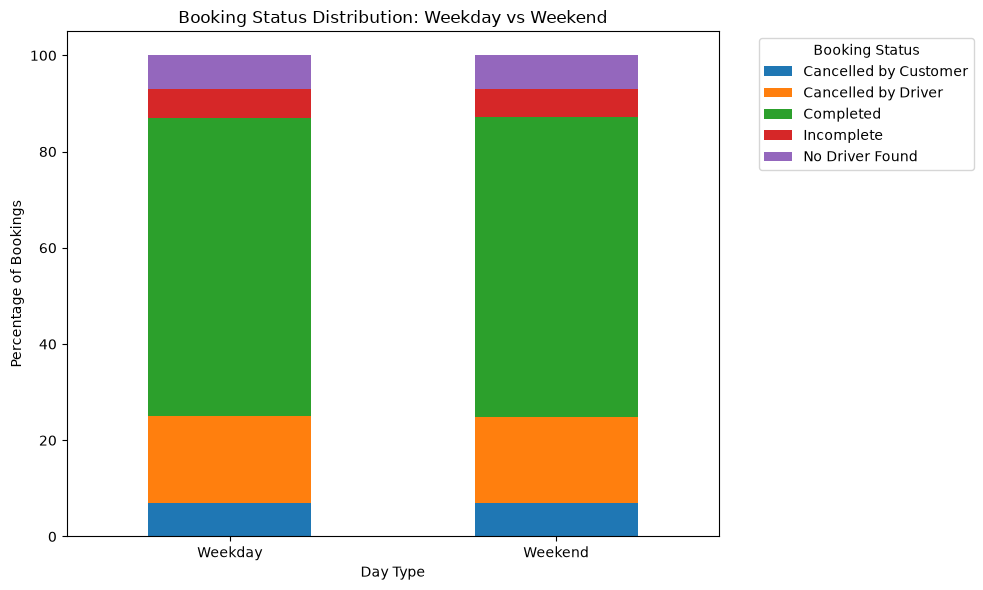

In [19]:
weekday_weekend_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Booking Status Distribution: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Percentage of Bookings')
plt.xticks(rotation=0)
plt.legend(
    title='Booking Status',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

### Key Observation

- Booking outcomes are highly similar between weekdays and weekends.
- **Weekend bookings have a slightly higher completion rate (62.31%)** compared with weekdays (61.88%).
- **Driver cancellation rate** is slightly higher on weekdays (18.02%) than weekends (17.95%).
- **Customer cancellation rate** is slightly higher on weekdays (7.04%) than weekends (6.90%).
- **No Driver Found** is slightly higher on weekdays (7.03%) compared with weekends (6.92%).
- Overall, the differences are small, suggesting that **weekday vs weekend alone has limited influence on booking outcomes**.

## 7.6 Hourly Booking Pattern

The hourly distribution of bookings was analyzed to identify peak and low-demand periods throughout the day.

In [20]:
hourly_bookings = data['Hour'].value_counts().sort_index()

print("Number of Bookings by Hour:")
display(hourly_bookings)

Number of Bookings by Hour:


Hour
0      1373
1      1360
2      1339
3      1383
4      1321
5      2786
6      4160
7      5450
8      6861
9      8234
10     9577
11     8390
12     7006
13     5470
14     7031
15     8202
16     9633
17    11044
18    12397
19    11047
20     9630
21     8103
22     5441
23     2762
Name: count, dtype: int64

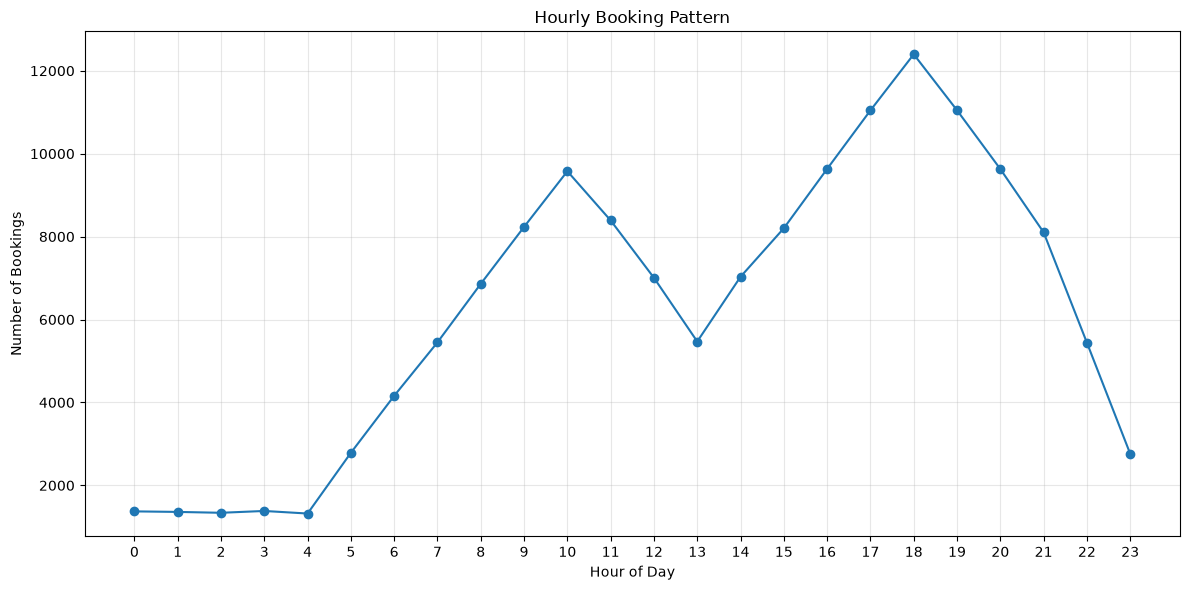

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_bookings.index,
    hourly_bookings.values,
    marker='o'
)

plt.title('Hourly Booking Pattern')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Bookings')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Key Observation

- Booking demand is relatively low during the early morning hours, especially between **00:00 and 04:00**.
- Booking volume starts increasing from **05:00 onwards** and rises significantly during the morning.
- The **highest booking volume occurs at 18:00 with 12,397 bookings**, indicating the strongest demand during the evening.
- The second-highest booking volume occurs at **19:00 with 11,047 bookings**, followed by **17:00 with 11,044 bookings**.
- Morning demand also shows a strong peak, with **10:00 recording 9,577 bookings**.
- After the evening peak, booking volume gradually declines and reaches **2,762 bookings at 23:00**.
- Overall, the data shows a clear **peak-demand period during the evening, particularly around 17:00–20:00**, while overnight and early-morning hours have substantially lower booking activity.

## 7.7 Customer Cancellation Reasons

Customer cancellation reasons were analyzed to identify the major factors contributing to customer-initiated ride cancellations.

In [22]:
customer_cancel_reasons = (
    data['Reason for cancelling by Customer']
    .dropna()
    .value_counts()
)

print("Customer Cancellation Reasons:")
display(customer_cancel_reasons)

Customer Cancellation Reasons:


Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
Name: count, dtype: int64

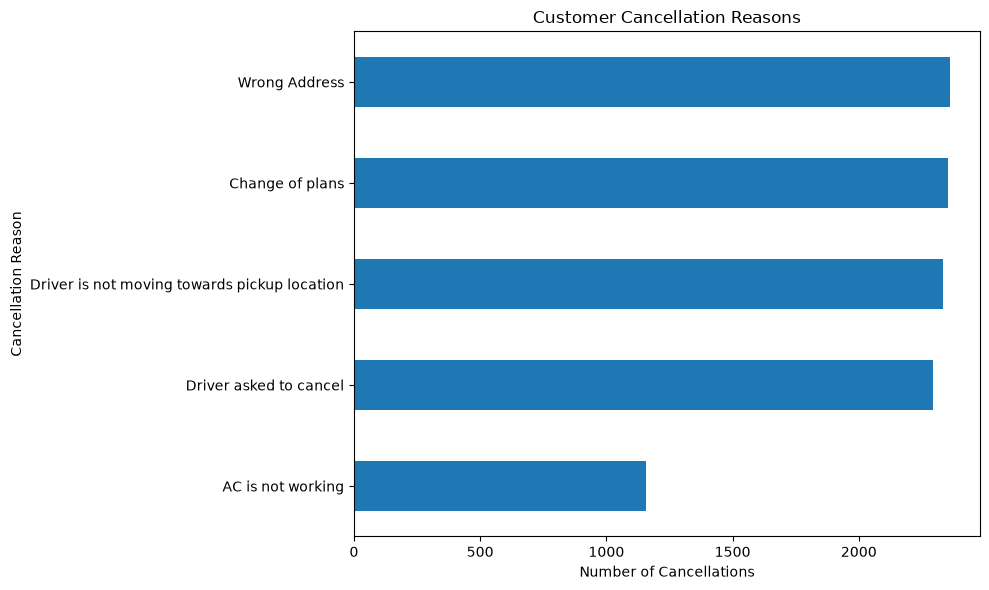

In [23]:
plt.figure(figsize=(10, 6))

customer_cancel_reasons.sort_values().plot(
    kind='barh'
)

plt.title('Customer Cancellation Reasons')
plt.xlabel('Number of Cancellations')
plt.ylabel('Cancellation Reason')
plt.tight_layout()
plt.show()

### Key Observation

- **Wrong Address** is the most common customer cancellation reason, with **2,362 cancellations**.
- **Change of plans** is the second most common reason, with **2,353 cancellations**.
- **Driver is not moving towards pickup location** accounts for **2,335 cancellations**.
- **Driver asked to cancel** accounts for **2,295 cancellations**.
- **AC is not working** is the least common reason, with **1,155 cancellations**.
- The first four reasons have relatively similar cancellation volumes, indicating that customer cancellations are driven by multiple factors rather than a single dominant issue.
- Operational issues involving driver movement and driver-requested cancellations together represent a significant portion of customer-initiated cancellations.

## 7.8 Driver Cancellation Reasons

Driver cancellation reasons were analyzed to identify the major factors contributing to driver-initiated ride cancellations.

In [24]:
driver_cancel_reasons = (
    data['Driver Cancellation Reason']
    .dropna()
    .value_counts()
)

print("Driver Cancellation Reasons:")
display(driver_cancel_reasons)

Driver Cancellation Reasons:


Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
Name: count, dtype: int64

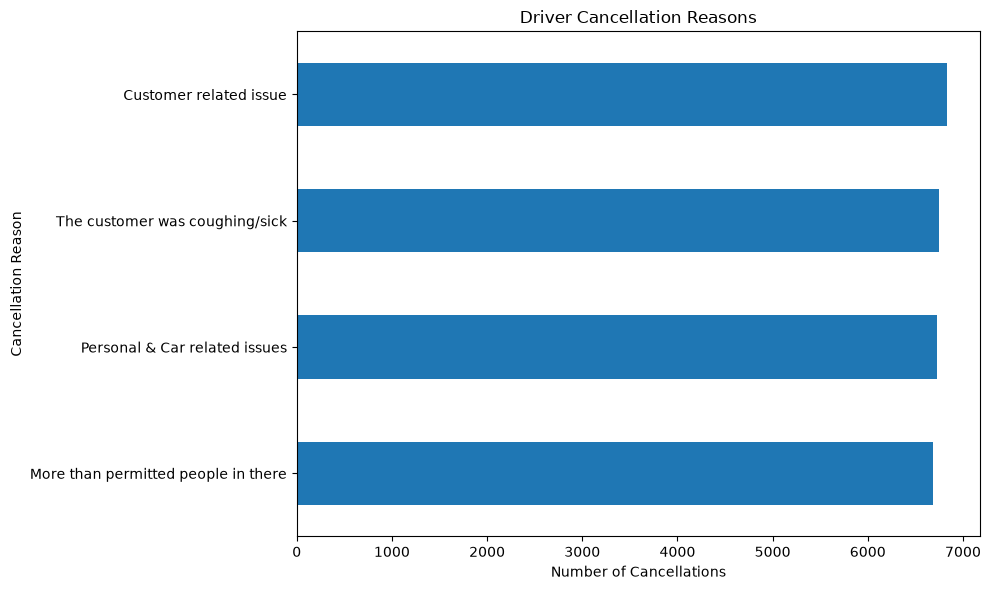

In [25]:
plt.figure(figsize=(10, 6))

driver_cancel_reasons.sort_values().plot(
    kind='barh'
)

plt.title('Driver Cancellation Reasons')
plt.xlabel('Number of Cancellations')
plt.ylabel('Cancellation Reason')
plt.tight_layout()
plt.show()

### Key Observation

- **Customer related issue** is the most common driver cancellation reason, with **6,837 cancellations**.
- **The customer was coughing/sick** is the second most common reason, with **6,751 cancellations**.
- **Personal & Car related issues** account for **6,726 cancellations**.
- **More than permitted people in the vehicle** accounts for **6,686 cancellations**.
- The difference between the most and least common reasons is relatively small, indicating that **driver cancellations are distributed across multiple operational and customer-related factors**.
- Customer-related issues and vehicle/personal constraints both contribute significantly to driver-initiated cancellations.

## 7.9 Incomplete Ride Reasons

The reasons for incomplete rides were analyzed to identify the major factors preventing bookings from reaching successful completion.

In [26]:
incomplete_ride_reasons = (
    data['Incomplete Rides Reason']
    .dropna()
    .value_counts()
)

print("Incomplete Ride Reasons:")
display(incomplete_ride_reasons)

Incomplete Ride Reasons:


Incomplete Rides Reason
Customer Demand      3040
Vehicle Breakdown    3012
Other Issue          2948
Name: count, dtype: int64

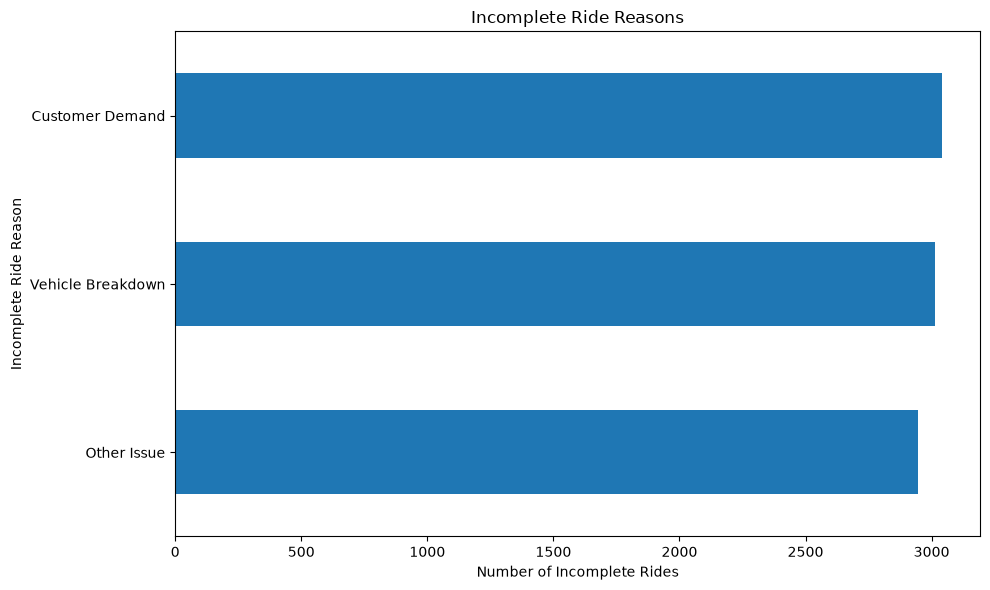

In [27]:
plt.figure(figsize=(10, 6))

incomplete_ride_reasons.sort_values().plot(
    kind='barh'
)

plt.title('Incomplete Ride Reasons')
plt.xlabel('Number of Incomplete Rides')
plt.ylabel('Incomplete Ride Reason')
plt.tight_layout()
plt.show()

### Key Observation

- **Customer Demand** is the most common reason for incomplete rides, with **3,040 cases**.
- **Vehicle Breakdown** accounts for **3,012 incomplete rides**.
- **Other Issue** accounts for **2,948 cases**, making it the least common reason.
- The difference between the most and least common reasons is relatively small, indicating that incomplete rides are caused by **multiple factors rather than one dominant issue**.
- Both customer-related demand and vehicle-related operational problems contribute meaningfully to incomplete rides.

## 7.10 Ride Distance by Booking Status

Ride distance was analyzed across booking statuses to understand whether trip length differs between completed and incomplete rides.

In [28]:
ride_distance_summary = (
    data.groupby('Booking Status')['Ride Distance']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

print("Ride Distance Summary by Booking Status:")
display(ride_distance_summary)

Ride Distance Summary by Booking Status:


,count,mean,median,min,max
Booking Status,,,,,
Cancelled by Customer,0,NaN,NaN,NaN,NaN
Cancelled by Driver,0,NaN,NaN,NaN,NaN
Completed,93000,26.00,26.02,2.0,50.0
Incomplete,9000,10.55,10.54,1.0,20.0
No Driver Found,0,NaN,NaN,NaN,NaN


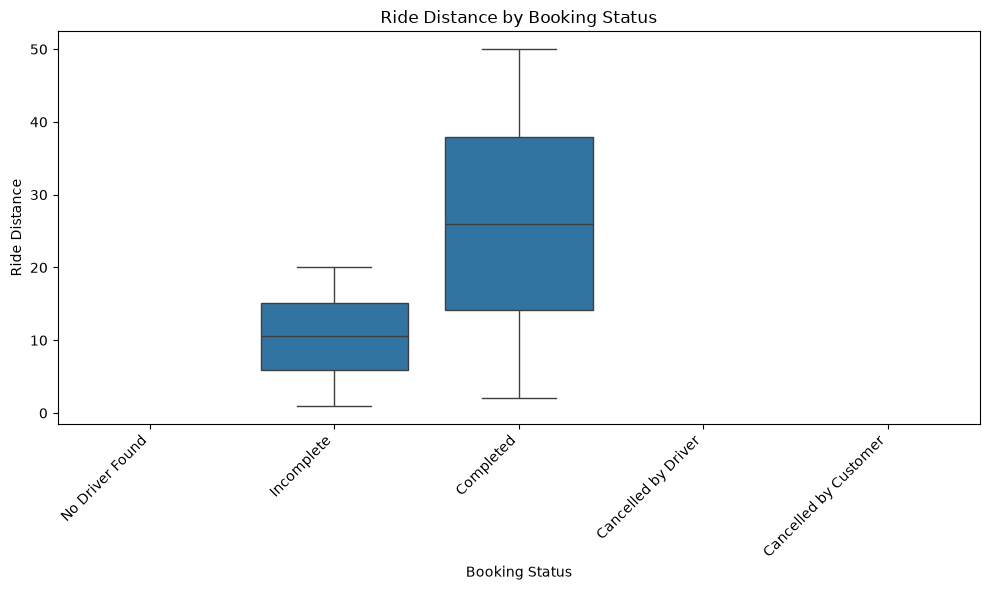

In [29]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x='Booking Status',
    y='Ride Distance'
)

plt.title('Ride Distance by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Ride Distance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Observation

- `Ride Distance` is available only for **Completed** and **Incomplete** bookings.
- Completed rides have an average ride distance of **26.00**, with a median of **26.02** and a range of **2 to 50**.
- Incomplete rides have a much shorter average distance of **10.55**, with a median of **10.54** and a range of **1 to 20**.
- `Ride Distance` is completely missing for **Cancelled by Customer**, **Cancelled by Driver**, and **No Driver Found** bookings.
- Therefore, the difference in ride distance between completed and incomplete rides should be interpreted carefully because the availability of this variable is itself related to booking outcome.
- This variable will therefore be treated as an **outcome-dependent feature** and excluded from the final machine-learning predictor set to avoid data leakage.

## 7.11 Booking Value by Booking Status

Booking value was analyzed across booking statuses to understand the value characteristics of completed and incomplete rides.

In [30]:
booking_value_summary = (
    data.groupby('Booking Status')['Booking Value']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

print("Booking Value Summary by Booking Status:")
display(booking_value_summary)

Booking Value Summary by Booking Status:


,count,mean,median,min,max
Booking Status,,,,,
Cancelled by Customer,0,NaN,NaN,NaN,NaN
Cancelled by Driver,0,NaN,NaN,NaN,NaN
Completed,93000,508.18,414.0,50.0,4277.0
Incomplete,9000,509.51,414.0,50.0,3878.0
No Driver Found,0,NaN,NaN,NaN,NaN


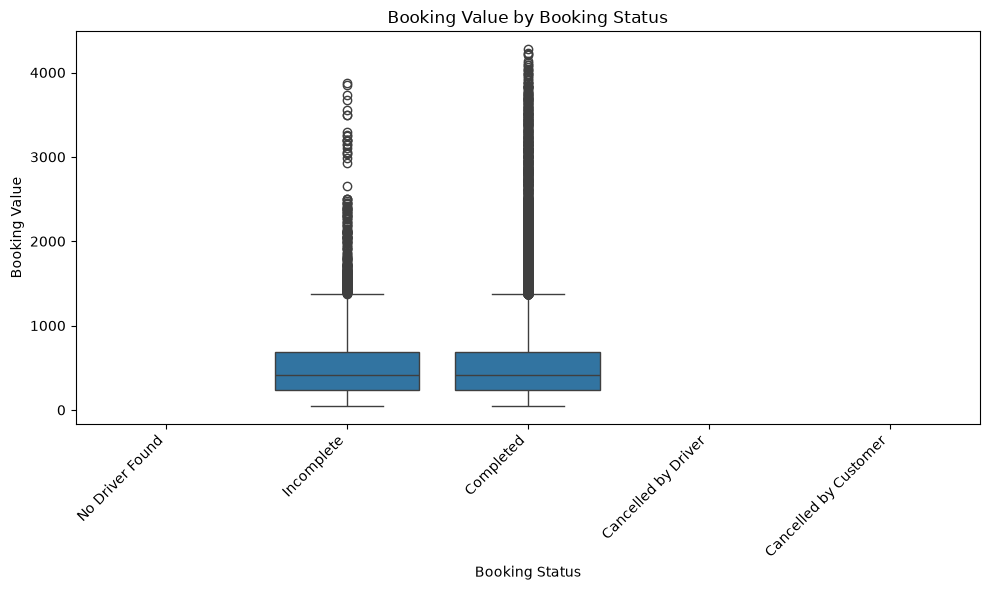

In [31]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x='Booking Status',
    y='Booking Value'
)

plt.title('Booking Value by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Booking Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Observation

- `Booking Value` is available only for **Completed** and **Incomplete** bookings.
- Completed rides have an average booking value of **508.18**, with a median of **414.00**.
- Incomplete rides have a slightly higher average booking value of **509.51**, while the median remains **414.00**.
- Completed bookings have a value range of **50 to 4,277**, while incomplete bookings range from **50 to 3,878**.
- The average and median booking values are very similar between completed and incomplete rides, indicating that booking value does not show a major difference between these two outcomes.
- `Booking Value` is completely missing for **Cancelled by Customer**, **Cancelled by Driver**, and **No Driver Found** bookings.
- Because the availability of `Booking Value` is directly related to the booking outcome, it will be treated as an **outcome-dependent feature** and excluded from the final machine-learning predictor set to avoid data leakage.

## 7.12 Avg VTAT by Booking Status

Average Vehicle Time of Arrival (Avg VTAT) was analyzed across booking statuses to understand whether driver arrival time is associated with different booking outcomes.

In [32]:
vtat_summary = (
    data.groupby('Booking Status')['Avg VTAT']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

print("Avg VTAT Summary by Booking Status:")
display(vtat_summary)

Avg VTAT Summary by Booking Status:


,count,mean,median,min,max
Booking Status,,,,,
Cancelled by Customer,10500,12.51,12.6,5.0,20.0
Cancelled by Driver,27000,7.50,7.5,3.0,12.0
Completed,93000,8.51,8.5,2.0,15.0
Incomplete,9000,6.01,6.0,2.0,10.0
No Driver Found,0,NaN,NaN,NaN,NaN


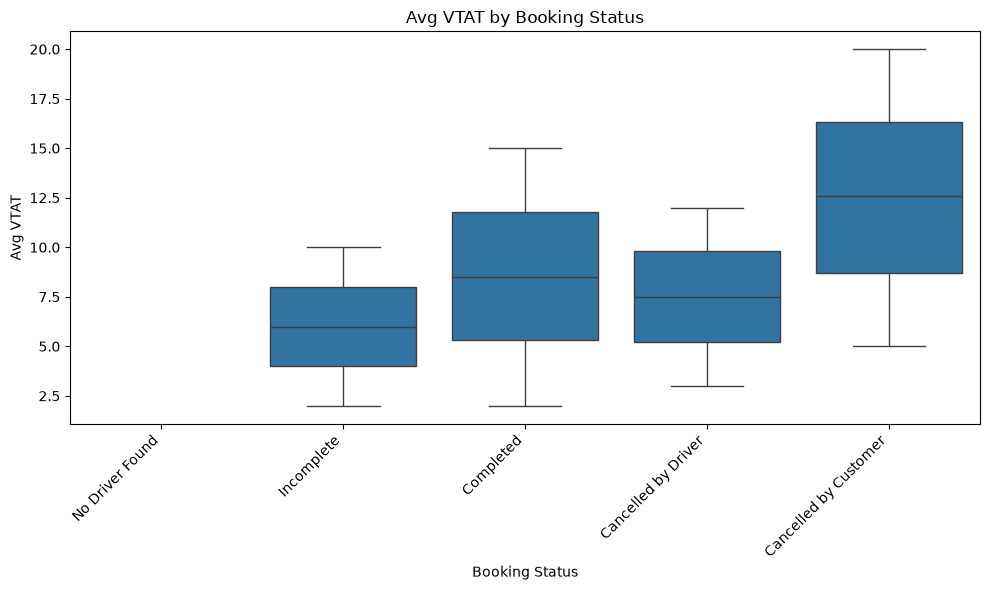

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x='Booking Status',
    y='Avg VTAT'
)

plt.title('Avg VTAT by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Avg VTAT')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Observation

- `Avg VTAT` is available for all booking outcomes except **No Driver Found**, where no vehicle was assigned.
- **Cancelled by Customer** bookings have the highest average VTAT at **12.51**, with a median of **12.60**.
- **Completed** bookings have an average VTAT of **8.51**, while **Cancelled by Driver** bookings have an average of **7.50**.
- **Incomplete** bookings have the lowest average VTAT at **6.01** among bookings where VTAT is available.
- The difference between customer cancellations and completed rides suggests that **longer estimated vehicle arrival times may be associated with higher customer cancellation risk**.
- The absence of VTAT for **No Driver Found** bookings is also operationally meaningful because no vehicle was assigned.
- Since `Avg VTAT` and its missingness are closely associated with booking outcomes, this variable requires special consideration during **ML feature selection and leakage analysis**.

## 7.13 Avg CTAT by Booking Status

Average CTAT was analyzed across booking statuses to understand whether this operational metric differs between completed and incomplete rides.

In [34]:
ctat_summary = (
    data.groupby('Booking Status')['Avg CTAT']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

print("Avg CTAT Summary by Booking Status:")
display(ctat_summary)

Avg CTAT Summary by Booking Status:


,count,mean,median,min,max
Booking Status,,,,,
Cancelled by Customer,0,NaN,NaN,NaN,NaN
Cancelled by Driver,0,NaN,NaN,NaN,NaN
Completed,93000,30.03,30.0,15.0,45.0
Incomplete,9000,20.00,20.0,10.0,30.0
No Driver Found,0,NaN,NaN,NaN,NaN


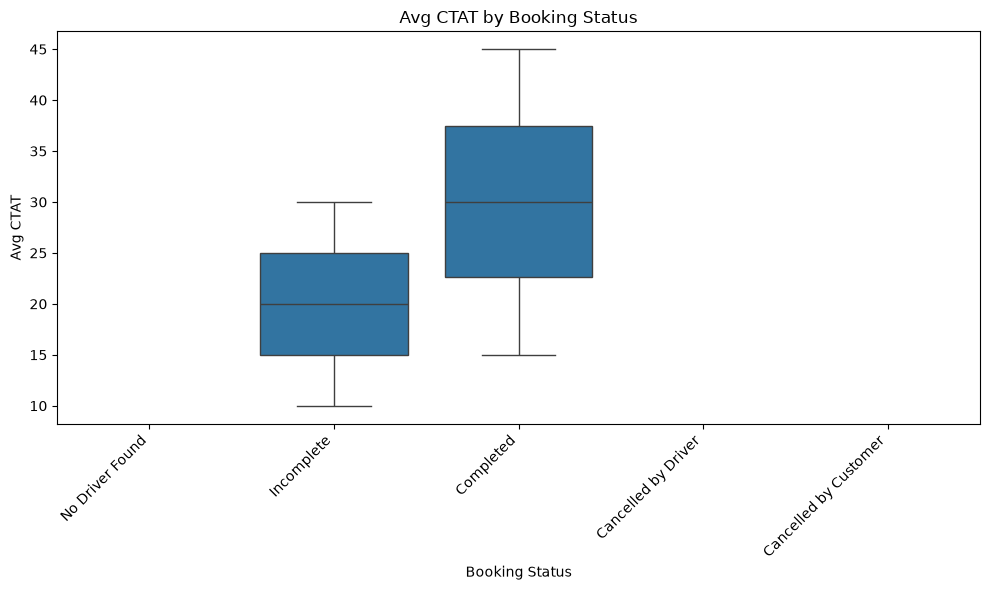

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x='Booking Status',
    y='Avg CTAT'
)

plt.title('Avg CTAT by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Avg CTAT')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Observation

- `Avg CTAT` is available only for **Completed** and **Incomplete** bookings.
- Completed rides have an average CTAT of **30.03**, with a median of **30.00**.
- Incomplete rides have a lower average CTAT of **20.00**, with a median of **20.00**.
- Completed rides have a CTAT range of **15 to 45**, while incomplete rides range from **10 to 30**.
- The difference between completed and incomplete rides indicates that `Avg CTAT` is strongly associated with the booking outcome.
- `Avg CTAT` is completely missing for **Cancelled by Customer**, **Cancelled by Driver**, and **No Driver Found** bookings.
- Because CTAT is available only after the booking progresses to a certain operational stage, it represents **outcome-dependent information** and will be excluded from the final machine-learning predictor set to avoid data leakage.

## 7.14 Driver and Customer Ratings by Booking Status

Driver and customer ratings were analyzed across booking statuses to understand whether rating patterns differ between successful and unsuccessful bookings.

In [36]:
driver_rating_summary = (
    data.groupby('Booking Status')['Driver Ratings']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

print("Driver Ratings Summary by Booking Status:")
display(driver_rating_summary)

Driver Ratings Summary by Booking Status:


,count,mean,median,min,max
Booking Status,,,,,
Cancelled by Customer,0,NaN,NaN,NaN,NaN
Cancelled by Driver,0,NaN,NaN,NaN,NaN
Completed,93000,4.23,4.3,3.0,5.0
Incomplete,0,NaN,NaN,NaN,NaN
No Driver Found,0,NaN,NaN,NaN,NaN


In [37]:
customer_rating_summary = (
    data.groupby('Booking Status')['Customer Rating']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

print("Customer Rating Summary by Booking Status:")
display(customer_rating_summary)

Customer Rating Summary by Booking Status:


,count,mean,median,min,max
Booking Status,,,,,
Cancelled by Customer,0,NaN,NaN,NaN,NaN
Cancelled by Driver,0,NaN,NaN,NaN,NaN
Completed,93000,4.4,4.5,3.0,5.0
Incomplete,0,NaN,NaN,NaN,NaN
No Driver Found,0,NaN,NaN,NaN,NaN


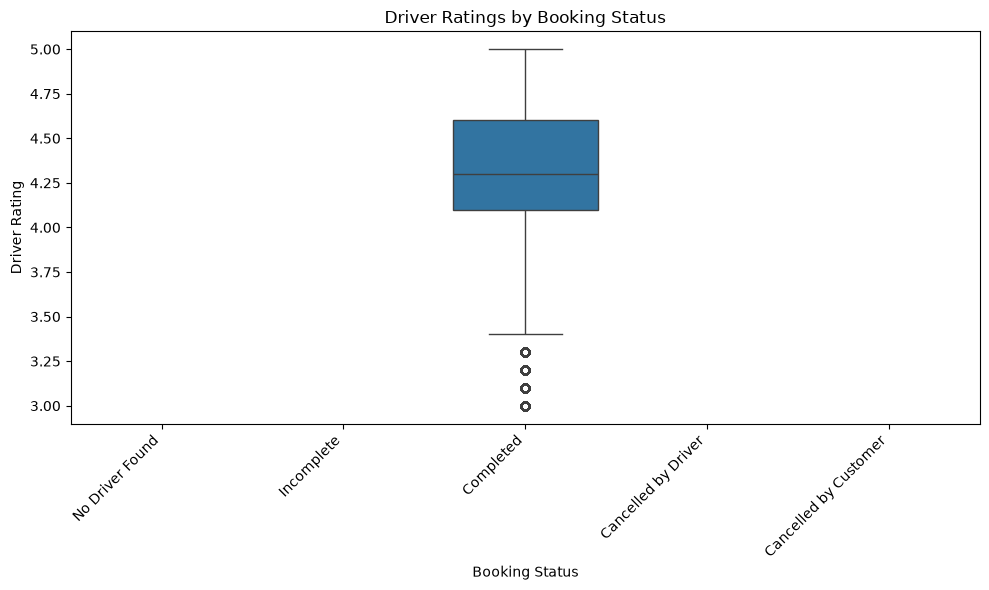

In [38]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x='Booking Status',
    y='Driver Ratings'
)

plt.title('Driver Ratings by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Driver Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

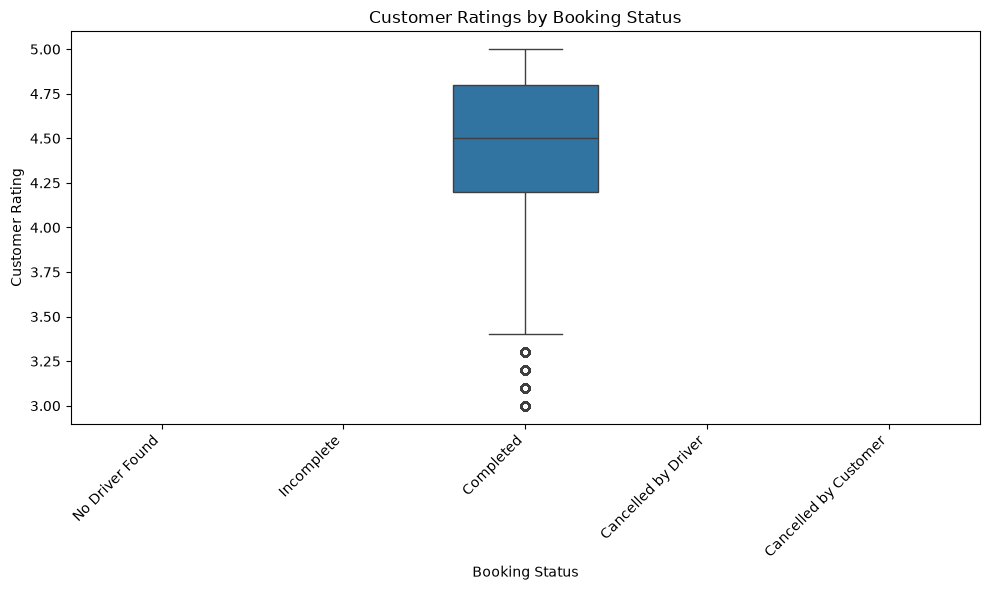

In [39]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x='Booking Status',
    y='Customer Rating'
)

plt.title('Customer Ratings by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Customer Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Observation

- `Driver Ratings` are available only for **Completed** bookings, with **93,000 records**.
- Completed rides have an average driver rating of **4.23**, with a median of **4.30** and a range of **3.0 to 5.0**.
- `Customer Rating` is also available only for **Completed** bookings, with **93,000 records**.
- Completed rides have an average customer rating of **4.40**, with a median of **4.50** and a range of **3.0 to 5.0**.
- Ratings are completely unavailable for cancelled and incomplete bookings.
- Since ratings are generated after a ride has progressed or completed, they are **outcome-dependent variables** and will not be used as predictors in the machine-learning model.

## 7.15 Booking Status by Payment Method

The relationship between payment method and booking status was analyzed to understand whether booking outcomes differ across payment methods.

In [40]:
payment_status_pct = pd.crosstab(
    data['Payment Method'],
    data['Booking Status'],
    normalize='index'
).mul(100).round(2)

print("Booking Status Distribution by Payment Method (%):")
display(payment_status_pct)

Booking Status Distribution by Payment Method (%):


Booking Status,Completed,Incomplete
Payment Method,,
Cash,91.12,8.88
Credit Card,91.29,8.71
Debit Card,91.35,8.65
UPI,91.12,8.88
Uber Wallet,91.28,8.72


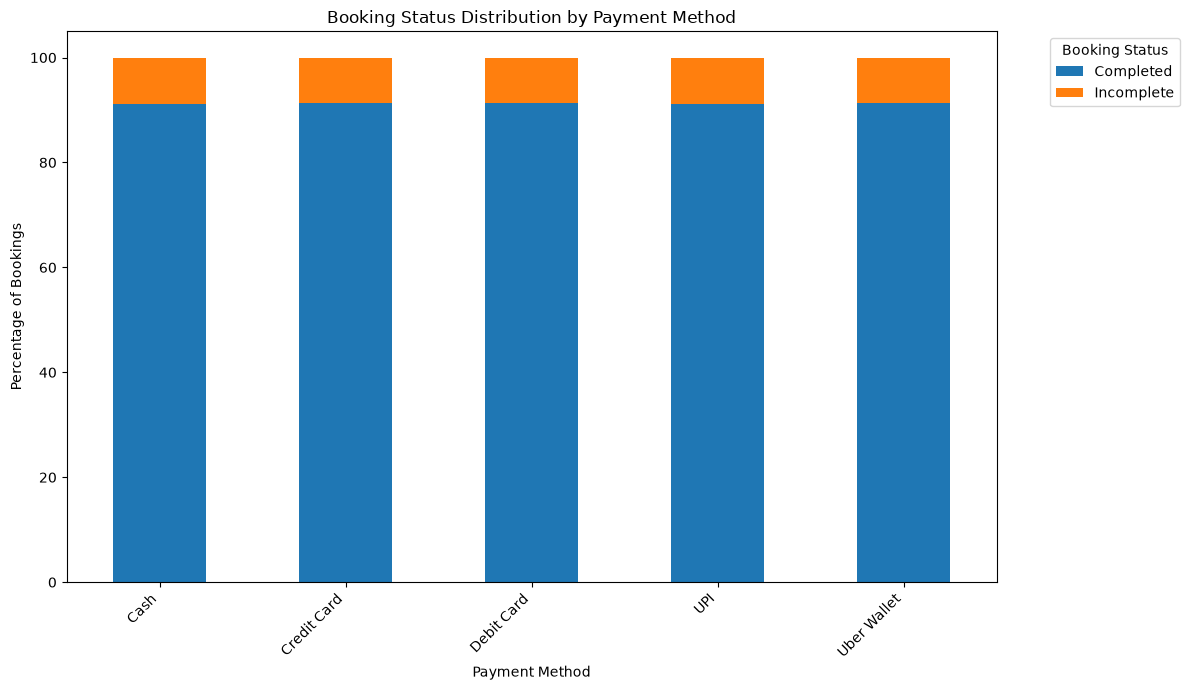

In [41]:
payment_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)

plt.title('Booking Status Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Percentage of Bookings')
plt.xticks(rotation=45, ha='right')
plt.legend(
    title='Booking Status',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

### Observation

Booking outcomes are highly consistent across payment methods. Completion rates range from 91.12% to 91.35%, while incomplete bookings range from 8.65% to 8.88%.

Debit Card shows the highest completion rate at 91.35%, while Cash and UPI show the lowest at 91.12%. The differences are very small, indicating that payment method alone is not a major determinant of booking outcome.

However, payment method contains substantial missing values that are associated with specific booking outcomes. Therefore, it will be reviewed separately during the missing-value and data-leakage analysis and will not be directly used as an ML predictor.

## 7.16 Top Pickup & Drop Locations

The top pickup and drop locations were analyzed to identify high-demand areas and understand the geographical distribution of bookings.

In [42]:
top_pickup = data['Pickup Location'].value_counts().head(10)

print("Top 10 Pickup Locations:")
display(top_pickup)

Top 10 Pickup Locations:


Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907
Name: count, dtype: int64

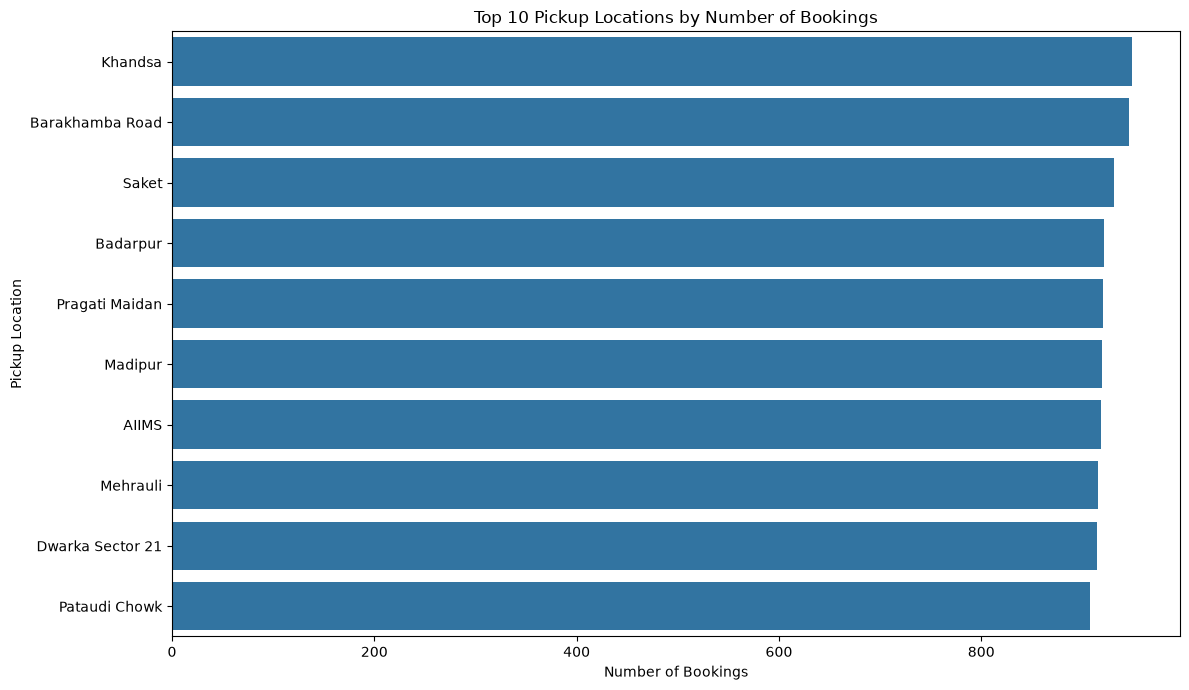

In [43]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_pickup.values,
    y=top_pickup.index
)

plt.title('Top 10 Pickup Locations by Number of Bookings')
plt.xlabel('Number of Bookings')
plt.ylabel('Pickup Location')
plt.tight_layout()
plt.show()

In [44]:
top_drop = data['Drop Location'].value_counts().head(10)

print("Top 10 Drop Locations:")
display(top_drop)

Top 10 Drop Locations:


Drop Location
Ashram                936
Basai Dhankot         917
Lok Kalyan Marg       916
Narsinghpur           913
Cyber Hub             912
Kalkaji               912
Kashmere Gate ISBT    909
Udyog Vihar           906
Lajpat Nagar          904
Madipur               902
Name: count, dtype: int64

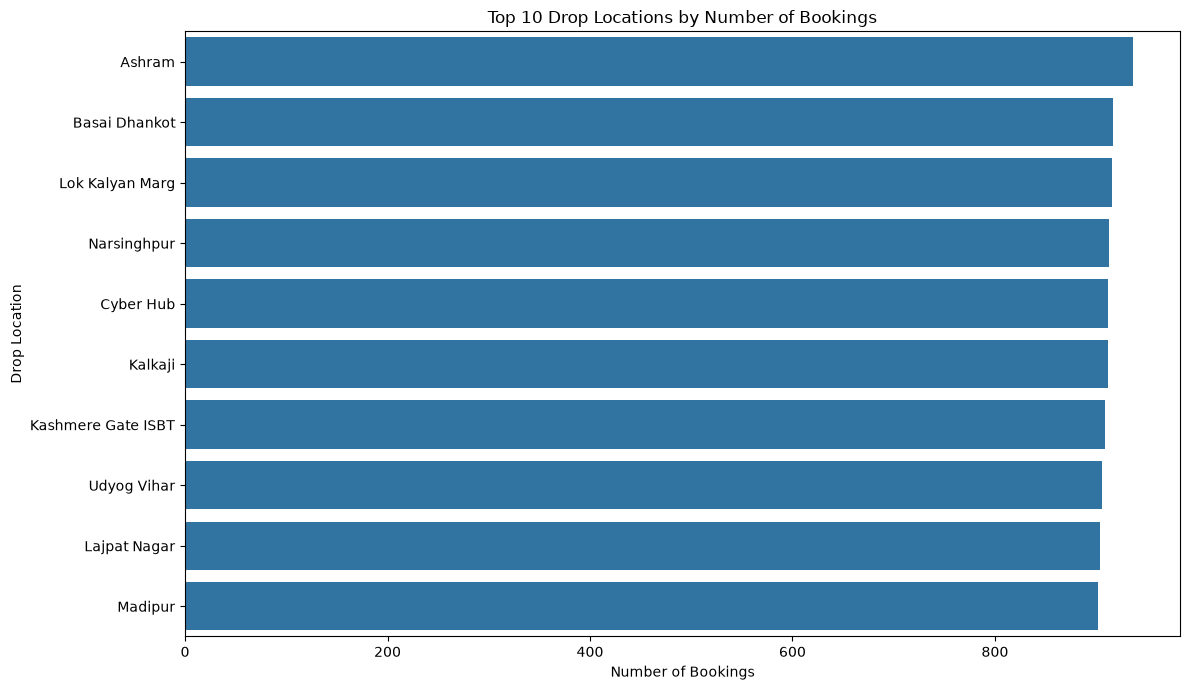

In [45]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_drop.values,
    y=top_drop.index
)

plt.title('Top 10 Drop Locations by Number of Bookings')
plt.xlabel('Number of Bookings')
plt.ylabel('Drop Location')
plt.tight_layout()
plt.show()

### Observation

The top pickup location is **Khandsa with 949 bookings**, followed by **Barakhamba Road with 946 bookings** and **Saket with 931 bookings**.

For drop locations, **Ashram has the highest number of bookings with 936**, followed by **Basai Dhankot with 917** and **Lok Kalyan Marg with 916**.

The booking counts across the top locations are relatively close, indicating that demand is distributed across multiple pickup and drop locations rather than being highly concentrated in a single area.

Location information may still provide useful signals for machine learning because booking outcomes can vary based on pickup and drop areas.

## 7.17 EDA Summary

The exploratory analysis identified several important patterns in booking outcomes, demand, operational factors, and customer and driver behavior.

| Analysis Area | Key Finding |
|---|---|
| Booking Status | 62% bookings were completed, while 38% were unsuccessful outcomes |
| Vehicle Type | Booking outcomes were relatively consistent across vehicle types |
| Day Period | Booking outcomes showed only small differences across Morning, Afternoon, Evening, and Night |
| Day of Week | Booking outcomes were relatively consistent across weekdays |
| Weekday vs Weekend | Weekend completion rate was slightly higher than weekday completion rate |
| Hourly Demand | Booking demand was highest during the evening, particularly around 17:00–20:00 |
| Customer Cancellation | Wrong Address and Change of Plans were among the most common customer cancellation reasons |
| Driver Cancellation | Customer-related issues and customer health-related issues were major driver cancellation reasons |
| Incomplete Rides | Customer Demand and Vehicle Breakdown were the leading incomplete ride reasons |
| Ride Distance | Available only for Completed and Incomplete bookings, indicating outcome-dependent availability |
| Booking Value | Available mainly for Completed and Incomplete bookings, indicating outcome-dependent availability |
| Avg VTAT | Customer cancellations had the highest average VTAT, while No Driver Found had missing VTAT values |
| Avg CTAT | Available mainly for Completed and Incomplete bookings and therefore outcome-dependent |
| Ratings | Driver and customer ratings were available only for Completed rides |
| Payment Method | Booking outcomes were highly consistent across payment methods |
| Pickup/Drop Locations | Demand was distributed across multiple locations without strong concentration in one location |

### Overall EDA Conclusion

EDA shows that booking outcomes are influenced by a combination of temporal, geographical, operational, and booking-related factors rather than a single variable.

The analysis also identified several variables whose availability depends on the booking outcome. Variables such as **Ride Distance, Booking Value, Avg CTAT, ratings, cancellation reasons, and incomplete ride reasons** are therefore treated carefully during machine learning to avoid data leakage.

The analysis also highlights **Avg VTAT and its missingness** as potentially important operational signals. However, these variables may represent information available after the booking process has already progressed. This limitation is addressed separately during the data leakage analysis.

The EDA findings provide the foundation for feature engineering, missing-value analysis, leakage assessment, and machine learning dataset preparation.

# 8. Feature Engineering

Feature engineering was performed to transform the existing date and time information into meaningful variables that can be used for analysis and machine learning.

The following features were created:

- **Hour:** Hour extracted from the booking time
- **Day_Period:** Morning, Afternoon, Evening, or Night
- **Day_of_Week:** Day name extracted from the booking date
- **Is_Weekend:** Indicates whether the booking occurred on a weekend
- **Year:** Year extracted from the booking date
- **Month:** Month extracted from the booking date
- **Day:** Day of the month extracted from the booking date

These features help capture temporal patterns in booking demand and booking outcomes.

In [46]:
# Feature Engineering - Time Based Features

data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day

data['Hour'] = data['Time'].apply(
    lambda x: x.hour if pd.notna(x) else None
)

data['Day_of_Week'] = data['Date'].dt.day_name()

data['Is_Weekend'] = data['Date'].dt.dayofweek.apply(
    lambda x: 1 if x >= 5 else 0
)

def get_day_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

data['Day_Period'] = data['Hour'].apply(get_day_period)

print("Feature engineering completed.")
print("New shape:", data.shape)

Feature engineering completed.
New shape: (150000, 28)


In [47]:
engineered_features = [
    'Hour',
    'Day_Period',
    'Day_of_Week',
    'Is_Weekend',
    'Year',
    'Month',
    'Day'
]

print("Engineered Features:")
display(data[engineered_features].head())

print("\nShape:", data.shape)

Engineered Features:


,Hour,Day_Period,Day_of_Week,Is_Weekend,Year,Month,Day
0,12,Afternoon,Saturday,1,2024,3,23
1,18,Evening,Friday,0,2024,11,29
2,8,Morning,Friday,0,2024,8,23
3,17,Evening,Monday,0,2024,10,21
4,22,Night,Monday,0,2024,9,16



Shape: (150000, 28)


In [48]:
print("Feature Details:\n")

for feature in engineered_features:
    print(f"{feature}:")
    print("  Unique values:", data[feature].nunique())
    print("  Missing values:", data[feature].isna().sum())
    print()

Feature Details:

Hour:
  Unique values: 24
  Missing values: 0

Day_Period:
  Unique values: 4
  Missing values: 0

Day_of_Week:
  Unique values: 7
  Missing values: 0

Is_Weekend:
  Unique values: 2
  Missing values: 0

Year:
  Unique values: 1
  Missing values: 0

Month:
  Unique values: 12
  Missing values: 0

Day:
  Unique values: 31
  Missing values: 0



### Observation

All engineered features were successfully created without missing values.

- `Hour` contains 24 unique values, representing hours from 0 to 23.
- `Day_Period` contains 4 categories: Morning, Afternoon, Evening, and Night.
- `Day_of_Week` contains all 7 days of the week.
- `Is_Weekend` contains two values representing weekday and weekend.
- `Year` contains one unique value because the dataset covers a single year.
- `Month` contains 12 unique values.
- `Day` contains 31 possible day values.

The dataset retains all **150,000 records and 28 columns** after feature engineering.

## 8.1 Time-Based Feature Engineering

The booking time was transformed into meaningful time-based features to capture variations in booking demand and booking outcomes throughout the day.

The `Hour` feature represents the hour of booking, while `Day_Period` groups bookings into four operational periods:

- Morning: 05:00–11:59
- Afternoon: 12:00–16:59
- Evening: 17:00–20:59
- Night: 21:00–04:59

These features allow the analysis and machine learning models to capture time-related patterns without directly using the original time field.

In [49]:
print("Hour Range:")
print("Minimum Hour:", data['Hour'].min())
print("Maximum Hour:", data['Hour'].max())

print("\nDay Period Distribution:")
display(data['Day_Period'].value_counts())

print("\nDay of Week Distribution:")
display(data['Day_of_Week'].value_counts())

Hour Range:
Minimum Hour: 0
Maximum Hour: 23

Day Period Distribution:


Day_Period
Morning      45458
Evening      44118
Afternoon    37342
Night        23082
Name: count, dtype: int64


Day of Week Distribution:


Day_of_Week
Monday       21644
Saturday     21542
Wednesday    21413
Sunday       21398
Friday       21397
Tuesday      21391
Thursday     21215
Name: count, dtype: int64

### Observation

The `Hour` feature covers the complete 24-hour range from 0 to 23, confirming that the time extraction was successful.

The `Day_Period` feature contains four categories. Morning has the highest number of bookings with **45,458**, followed by Evening with **44,118**, Afternoon with **37,342**, and Night with **23,082**.

The `Day_of_Week` feature contains all seven days, with booking counts relatively evenly distributed. Monday has the highest number of bookings at **21,644**, while Thursday has the lowest at **21,215**.

These features successfully capture the temporal characteristics of the booking data and can be used as predictors for machine learning.

## 8.2 Date-Based Feature Engineering

Date information was transformed into separate calendar-based features to capture seasonal and weekly booking patterns.

The following features were created:

- **Year:** Calendar year of the booking
- **Month:** Calendar month of the booking
- **Day:** Day of the month
- **Is_Weekend:** Binary indicator identifying weekend bookings

These features allow the model to capture calendar-based patterns without directly using the original date field.

In [50]:
print("Year Distribution:")
display(data['Year'].value_counts().sort_index())

print("\nMonth Distribution:")
display(data['Month'].value_counts().sort_index())

print("\nIs Weekend Distribution:")
display(data['Is_Weekend'].value_counts().sort_index())

print("\nDay Range:")
print("Minimum Day:", data['Day'].min())
print("Maximum Day:", data['Day'].max())

Year Distribution:


Year
2024    150000
Name: count, dtype: int64


Month Distribution:


Month
1     12861
2     11927
3     12719
4     12199
5     12778
6     12440
7     12897
8     12636
9     12248
10    12651
11    12394
12    12250
Name: count, dtype: int64


Is Weekend Distribution:


Is_Weekend
0    107060
1     42940
Name: count, dtype: int64


Day Range:
Minimum Day: 1
Maximum Day: 31


### Observation

The dataset contains bookings from a single year, **2024**, with all 150,000 records belonging to this year.

Bookings are distributed across all 12 months. July has the highest number of bookings with **12,897**, while February has the lowest with **11,927**. Overall, monthly booking volumes are relatively balanced.

The `Is_Weekend` feature contains **107,060 weekday bookings** and **42,940 weekend bookings**, indicating that approximately 28.63% of bookings occurred on weekends.

The `Day` feature ranges from **1 to 31**, covering all possible calendar day values.

Since the dataset contains only one year, the `Year` feature has limited predictive value and may not provide meaningful variation for machine learning.

In [51]:
weekend_check = pd.crosstab(
    data['Day_of_Week'],
    data['Is_Weekend']
)

print("Weekend Feature Validation:")
display(weekend_check)

Weekend Feature Validation:


Is_Weekend,0,1
Day_of_Week,,
Friday,21397,0
Monday,21644,0
Saturday,0,21542
Sunday,0,21398
Thursday,21215,0
Tuesday,21391,0
Wednesday,21413,0


### Observation

The `Is_Weekend` feature was validated against the `Day_of_Week` feature.

All Monday-to-Friday bookings are correctly assigned `Is_Weekend = 0`, while all Saturday and Sunday bookings are correctly assigned `Is_Weekend = 1`.

No inconsistent records were identified, confirming that the weekend feature was created correctly.

In [52]:
feature_check = [
    'Hour',
    'Day_Period',
    'Day_of_Week',
    'Is_Weekend',
    'Year',
    'Month',
    'Day'
]

verification = pd.DataFrame({
    'Feature': feature_check,
    'Data Type': [data[col].dtype for col in feature_check],
    'Unique Values': [data[col].nunique() for col in feature_check],
    'Missing Values': [data[col].isna().sum() for col in feature_check]
})

display(verification)

print("\nFinal Dataset Shape:", data.shape)
print("Total Missing Values in Engineered Features:",
      verification['Missing Values'].sum())

,Feature,Data Type,Unique Values,Missing Values
0,Hour,int64,24,0
1,Day_Period,str,4,0
2,Day_of_Week,str,7,0
3,Is_Weekend,int64,2,0
4,Year,int32,1,0
5,Month,int32,12,0
6,Day,int32,31,0



Final Dataset Shape: (150000, 28)
Total Missing Values in Engineered Features: 0


### Observation

The final verification confirms that all engineered features were created successfully.

All seven engineered features contain **zero missing values**, and their unique-value ranges are consistent with their intended definitions.

The dataset retains **150,000 records and 28 columns** after feature engineering.

Therefore, the feature engineering process is complete and the engineered features are ready for further analysis and machine learning preparation.

# 9. Missing Value Analysis

Missing value analysis was performed to understand the extent and distribution of missing data across the dataset.

The analysis focuses on:

- Missing value counts and percentages
- Missingness by booking status
- Outcome-dependent missingness
- Features that may introduce data leakage
- Appropriate treatment of missing values for machine learning

Missing values are not automatically treated as errors because, in some operational fields, the absence of a value may itself contain meaningful information.

In [53]:
missing_summary = pd.DataFrame({
    'Missing Values': data.isna().sum(),
    'Missing Percentage': (
        data.isna().sum() / len(data) * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary['Missing Values'] > 0
].sort_values(
    'Missing Values',
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage
Incomplete Rides,141000,94.0
Incomplete Rides Reason,141000,94.0
Cancelled Rides by Customer,139500,93.0
Reason for cancelling by Customer,139500,93.0
Cancelled Rides by Driver,123000,82.0
Driver Cancellation Reason,123000,82.0
Driver Ratings,57000,38.0
Customer Rating,57000,38.0
Avg CTAT,48000,32.0
Ride Distance,48000,32.0


### 9.1 Overall Missing Value Summary

The dataset contains missing values in several operational, cancellation, ride, payment, and rating-related features.

The highest missingness is observed in `Incomplete Rides` and `Incomplete Rides Reason`, with **94% missing values**. This is followed by customer cancellation fields with **93% missing values** and driver cancellation fields with **82% missing values**.

`Driver Ratings` and `Customer Rating` have **38% missing values**, while `Avg CTAT`, `Ride Distance`, `Booking Value`, and `Payment Method` each have **32% missing values**.

`Avg VTAT` has the lowest missingness among the affected features at **7%**.

However, these missing values may not represent random data loss. Several fields are only applicable to specific booking outcomes. Therefore, missingness will be analyzed against `Booking Status` before deciding how these variables should be handled for machine learning.

In [54]:
missing_features = [
    'Incomplete Rides',
    'Incomplete Rides Reason',
    'Cancelled Rides by Customer',
    'Reason for cancelling by Customer',
    'Cancelled Rides by Driver',
    'Driver Cancellation Reason',
    'Driver Ratings',
    'Customer Rating',
    'Avg CTAT',
    'Ride Distance',
    'Booking Value',
    'Payment Method',
    'Avg VTAT'
]

for feature in missing_features:
    print(f"{feature}")
    
    status_missing = pd.crosstab(
        data['Booking Status'],
        data[feature].isna()
    )
    
    status_missing.columns = ['Not Missing', 'Missing']
    
    display(status_missing)

Incomplete Rides


,Not Missing,Missing
Booking Status,,
Cancelled by Customer,0,10500
Cancelled by Driver,0,27000
Completed,0,93000
Incomplete,9000,0
No Driver Found,0,10500


Incomplete Rides Reason


,Not Missing,Missing
Booking Status,,
Cancelled by Customer,0,10500
Cancelled by Driver,0,27000
Completed,0,93000
Incomplete,9000,0
No Driver Found,0,10500


Cancelled Rides by Customer


...

,Not Missing,Missing
Booking Status,,
Cancelled by Customer,0,10500
Cancelled by Driver,0,27000
Completed,93000,0
Incomplete,9000,0
No Driver Found,0,10500


Payment Method


,Not Missing,Missing
Booking Status,,
Cancelled by Customer,0,10500
Cancelled by Driver,0,27000
Completed,93000,0
Incomplete,9000,0
No Driver Found,0,10500


Avg VTAT


,Not Missing,Missing
Booking Status,,
Cancelled by Customer,10500,0
Cancelled by Driver,27000,0
Completed,93000,0
Incomplete,9000,0
No Driver Found,0,10500


### 9.2 Missing Values by Booking Status

The missing-value analysis shows that missingness is strongly dependent on booking outcome rather than being random.

Several features have an outcome-specific availability pattern:

- `Incomplete Rides` and `Incomplete Rides Reason` are populated only for **Incomplete** bookings.
- `Cancelled Rides by Customer` and `Reason for cancelling by Customer` are populated only for **Cancelled by Customer** bookings.
- `Cancelled Rides by Driver` and `Driver Cancellation Reason` are populated only for **Cancelled by Driver** bookings.
- `Driver Ratings` and `Customer Rating` are available only for **Completed** bookings.
- `Avg CTAT`, `Ride Distance`, and `Booking Value` are available only for **Completed** and **Incomplete** bookings.
- `Payment Method` follows the same outcome-dependent availability pattern as these ride-level fields.
- `Avg VTAT` is available for all booking outcomes except **No Driver Found**, where it is completely missing.

This confirms that missingness in several variables carries direct information about the booking outcome.

Therefore, simply imputing these missing values and using the variables as machine learning predictors could introduce **data leakage**. These features will be reviewed carefully during the dedicated leakage analysis before final ML feature selection.

In [55]:
missing_pattern_summary = pd.DataFrame({
    'Feature': missing_summary.index,
    'Missing %': missing_summary['Missing Percentage'].values
})

missing_pattern_summary['Pattern'] = [
    'Outcome-dependent: Incomplete bookings',
    'Outcome-dependent: Incomplete bookings',
    'Outcome-dependent: Customer cancellations',
    'Outcome-dependent: Customer cancellations',
    'Outcome-dependent: Driver cancellations',
    'Outcome-dependent: Driver cancellations',
    'Outcome-dependent: Completed bookings',
    'Outcome-dependent: Completed bookings',
    'Outcome-dependent: Completed/Incomplete',
    'Outcome-dependent: Completed/Incomplete',
    'Outcome-dependent: Completed/Incomplete',
    'Outcome-dependent: Completed/Incomplete',
    'Outcome-dependent: No Driver Found'
]

display(missing_pattern_summary)

,Feature,Missing %,Pattern
0,Incomplete Rides,94.0,Outcome-dependent: Incomplete bookings
1,Incomplete Rides Reason,94.0,Outcome-dependent: Incomplete bookings
2,Cancelled Rides by Customer,93.0,Outcome-dependent: Customer cancellations
3,Reason for cancelling by Customer,93.0,Outcome-dependent: Customer cancellations
4,Cancelled Rides by Driver,82.0,Outcome-dependent: Driver cancellations
5,Driver Cancellation Reason,82.0,Outcome-dependent: Driver cancellations
6,Driver Ratings,38.0,Outcome-dependent: Completed bookings
7,Customer Rating,38.0,Outcome-dependent: Completed bookings
8,Avg CTAT,32.0,Outcome-dependent: Completed/Incomplete
9,Ride Distance,32.0,Outcome-dependent: Completed/Incomplete


### 9.3 Missing Value Pattern Summary

The missing-value patterns show that most missing values are **structurally related to the booking outcome** rather than occurring randomly.

Key observations:

* `Incomplete Rides` and `Incomplete Rides Reason` are missing for **94%** of records and are populated only for Incomplete bookings.
* Customer cancellation fields are missing for **93%** of records and are populated only when the customer cancels.
* Driver cancellation fields are missing for **82%** of records and are populated only when the driver cancels.
* `Driver Ratings` and `Customer Rating` are missing for **38%** of records and are available only for Completed bookings.
* `Avg CTAT`, `Ride Distance`, `Booking Value`, and `Payment Method` are missing for **32%** of records and are available only for Completed and Incomplete bookings.
* `Avg VTAT` has the lowest missing percentage at **7%**, but its missingness is completely associated with the **No Driver Found** outcome.

### Key Conclusion

The analysis confirms that missingness itself contains information about the booking outcome.

Therefore, these variables should **not be blindly imputed and used as machine learning predictors**. Doing so could allow the model to indirectly identify the target variable and introduce **data leakage**.

The affected features will be reviewed in detail during the next section, **Data Leakage Analysis**, before finalizing the machine learning feature set.


In [56]:
missing_category_summary = pd.DataFrame({
    'Feature': missing_summary.index,
    'Missing %': missing_summary['Missing Percentage'].values
})

missing_category_summary['Severity'] = pd.cut(
    missing_category_summary['Missing %'],
    bins=[0, 10, 30, 60, 100],
    labels=['Low', 'Moderate', 'High', 'Very High'],
    include_lowest=True
)

display(missing_category_summary)

,Feature,Missing %,Severity
0,Incomplete Rides,94.0,Very High
1,Incomplete Rides Reason,94.0,Very High
2,Cancelled Rides by Customer,93.0,Very High
3,Reason for cancelling by Customer,93.0,Very High
4,Cancelled Rides by Driver,82.0,Very High
5,Driver Cancellation Reason,82.0,Very High
6,Driver Ratings,38.0,High
7,Customer Rating,38.0,High
8,Avg CTAT,32.0,High
9,Ride Distance,32.0,High


### 9.4 Missing Value Severity

The severity analysis shows that:

* Six features have **Very High** missingness above 80%.
* Six features have **High** missingness between 30% and 60%.
* `Avg VTAT` has relatively **Low** missingness at 7%.
* However, missing-value percentage alone does not determine whether a feature should be used in machine learning.
* The earlier outcome-level analysis showed that the missingness is strongly associated with specific booking statuses.

Therefore, features with high or very high missingness will be considered carefully during **Data Leakage Analysis** rather than being automatically removed or imputed.


# 10. Data Leakage Analysis

Data leakage occurs when information that would not be legitimately available at the prediction stage is used as a machine learning feature.

Since the objective is to predict `Booking Status`, each feature must be evaluated based on:

* Whether it is available before or during the prediction stage
* Whether it is directly derived from the booking outcome
* Whether its missingness reveals the booking outcome
* Whether it represents post-ride information
* Whether it is an identifier rather than a useful predictive feature

The leakage analysis is used to determine which features should be included in the final machine learning dataset.


In [57]:
leakage_review = pd.DataFrame({
    'Feature': data.columns,
    'Missing %': (
        data.isna().sum() / len(data) * 100
    ).round(2)
})

leakage_review['Risk Category'] = 'To Review'

display(leakage_review)

,Feature,Missing %,Risk Category
Date,Date,0.0,To Review
Time,Time,0.0,To Review
Booking ID,Booking ID,0.0,To Review
Booking Status,Booking Status,0.0,To Review
Customer ID,Customer ID,0.0,To Review
Vehicle Type,Vehicle Type,0.0,To Review
Pickup Location,Pickup Location,0.0,To Review
Drop Location,Drop Location,0.0,To Review
Avg VTAT,Avg VTAT,7.0,To Review
Avg CTAT,Avg CTAT,32.0,To Review


In [58]:
leakage_classification = {
    'Date': 'Safe',
    'Time': 'Replace with engineered time features',
    'Booking ID': 'Identifier',
    'Booking Status': 'Target',
    'Customer ID': 'Identifier',
    'Vehicle Type': 'Safe',
    'Pickup Location': 'Safe',
    'Drop Location': 'Safe',
    
    'Avg VTAT': 'Caution - Operational Stage',
    'Avg CTAT': 'Leakage - Outcome Dependent',
    
    'Cancelled Rides by Customer': 'Leakage - Outcome Dependent',
    'Reason for cancelling by Customer': 'Leakage - Outcome Dependent',
    'Cancelled Rides by Driver': 'Leakage - Outcome Dependent',
    'Driver Cancellation Reason': 'Leakage - Outcome Dependent',
    'Incomplete Rides': 'Leakage - Outcome Dependent',
    'Incomplete Rides Reason': 'Leakage - Outcome Dependent',
    
    'Booking Value': 'Leakage - Outcome Dependent',
    'Ride Distance': 'Leakage - Outcome Dependent',
    'Driver Ratings': 'Leakage - Post Ride',
    'Customer Rating': 'Leakage - Post Ride',
    'Payment Method': 'Leakage - Outcome Dependent',
    
    'Year': 'Safe - Limited Variation',
    'Month': 'Safe',
    'Day': 'Safe',
    'Hour': 'Safe',
    'Day_of_Week': 'Safe',
    'Is_Weekend': 'Safe',
    'Day_Period': 'Safe'
}

leakage_review['Risk Category'] = leakage_review['Feature'].map(
    leakage_classification
)

display(leakage_review)

,Feature,Missing %,Risk Category
Date,Date,0.0,Safe
Time,Time,0.0,Replace with engineered time features
Booking ID,Booking ID,0.0,Identifier
Booking Status,Booking Status,0.0,Target
Customer ID,Customer ID,0.0,Identifier
Vehicle Type,Vehicle Type,0.0,Safe
Pickup Location,Pickup Location,0.0,Safe
Drop Location,Drop Location,0.0,Safe
Avg VTAT,Avg VTAT,7.0,Caution - Operational Stage
Avg CTAT,Avg CTAT,32.0,Leakage - Outcome Dependent


### 10.3 Leakage Classification Interpretation

The feature review identifies four major groups.

#### 🟢 Safe Features

These features are reasonably available before or during the booking process and do not directly reveal the booking outcome:

* `Date`
* `Vehicle Type`
* `Pickup Location`
* `Drop Location`
* `Month`
* `Day`
* `Hour`
* `Day_of_Week`
* `Is_Weekend`
* `Day_Period`

`Year` is also retained as a safe feature, although it has limited predictive value because the dataset contains only records from 2024.

#### 🟡 Caution — Operational Stage

`Avg VTAT` is treated separately because it represents **estimated vehicle arrival time** and is available during the operational/dispatch stage.

It can therefore provide useful information about booking outcomes, but it may not be available at the exact moment a booking is initially created.

For this reason, the project will treat `Avg VTAT` as an **operational-stage feature** and clearly document this limitation.

#### 🔴 Leakage / Outcome-Dependent Features

The following features are excluded because their values or missingness depend directly on the booking outcome:

* `Avg CTAT`
* `Cancelled Rides by Customer`
* `Reason for cancelling by Customer`
* `Cancelled Rides by Driver`
* `Driver Cancellation Reason`
* `Incomplete Rides`
* `Incomplete Rides Reason`
* `Booking Value`
* `Ride Distance`
* `Payment Method`

Using these variables could allow the model to identify the outcome indirectly rather than genuinely learning predictive patterns.

#### 🔴 Post-Ride Features

The following features are excluded because they are available only after the ride outcome:

* `Driver Ratings`
* `Customer Rating`

These features cannot legitimately be used to predict the booking outcome because they are generated after the ride has already occurred.

#### ⚪ Identifier Features

The following fields are excluded because they are identifiers rather than meaningful predictive variables:

* `Booking ID`
* `Customer ID`

High-cardinality identifiers can cause the model to memorize individual records or customers instead of learning generalizable patterns.

#### Time Representation

The original `Time` field will not be used directly.

Instead, the engineered features `Hour`, `Day_Period`, and `Day_of_Week` provide a more useful numerical and categorical representation of booking time.

### Overall Decision

The final machine learning dataset will primarily use safe booking, location, vehicle, and temporal features, with `Avg VTAT` handled separately as an operational-stage feature.


In [59]:
ml_features = [
    'Vehicle Type',
    'Pickup Location',
    'Drop Location',
    'Avg VTAT',
    'Hour',
    'Day_of_Week',
    'Day_Period',
    'Is_Weekend',
    'Year',
    'Month',
    'Day'
]

target = 'Booking Status'

print("ML Features:")
for i, feature in enumerate(ml_features, 1):
    print(f"{i}. {feature}")

print("\nTarget:")
print(target)

print("\nNumber of ML features:", len(ml_features))

ML Features:
1. Vehicle Type
2. Pickup Location
3. Drop Location
4. Avg VTAT
5. Hour
6. Day_of_Week
7. Day_Period
8. Is_Weekend
9. Year
10. Month
11. Day

Target:
Booking Status

Number of ML features: 11


### 10.5 Final Leakage Decision

After reviewing missing-value patterns, feature availability, and the relationship between variables and `Booking Status`, the following decisions were made:

| Feature Group          | Decision             | Reason                                  |
| ---------------------- | -------------------- | --------------------------------------- |
| Vehicle Type           | Include              | Available during booking                |
| Pickup Location        | Include              | Available during booking                |
| Drop Location          | Include              | Available during booking                |
| Hour                   | Include              | Derived from booking time               |
| Day of Week            | Include              | Derived from booking date               |
| Day Period             | Include              | Derived from booking time               |
| Is Weekend             | Include              | Derived from booking date               |
| Year                   | Include              | Temporal feature, but limited variation |
| Month                  | Include              | Temporal feature                        |
| Day                    | Include              | Temporal feature                        |
| Avg VTAT               | Include with caution | Operational/dispatch-stage signal       |
| Avg CTAT               | Exclude              | Outcome-dependent                       |
| Cancellation fields    | Exclude              | Directly related to booking outcome     |
| Incomplete ride fields | Exclude              | Directly related to booking outcome     |
| Booking Value          | Exclude              | Outcome-dependent availability          |
| Ride Distance          | Exclude              | Outcome-dependent availability          |
| Payment Method         | Exclude              | Outcome-dependent missingness           |
| Driver Rating          | Exclude              | Post-ride information                   |
| Customer Rating        | Exclude              | Post-ride information                   |
| Booking ID             | Exclude              | Identifier                              |
| Customer ID            | Exclude              | Identifier                              |
| Original Time          | Exclude              | Replaced by engineered time features    |

### Final ML Feature Set

The candidate feature set contains **11 features**:

* `Vehicle Type`
* `Pickup Location`
* `Drop Location`
* `Avg VTAT`
* `Hour`
* `Day_of_Week`
* `Day_Period`
* `Is_Weekend`
* `Year`
* `Month`
* `Day`

The target variable is:

* `Booking Status`

### Important Modeling Caveat

`Avg VTAT` is retained because it represents an operational-stage signal rather than a post-ride variable. However, its missingness is completely associated with `No Driver Found`.

Therefore, the final analysis will explicitly compare model performance **with and without `Avg VTAT`**.

This provides a more transparent assessment of how much predictive power comes from operational-stage information.


In [60]:
ml_data = data[ml_features + [target]].copy()

print("ML Dataset Shape:", ml_data.shape)
print("\nML Dataset Columns:")
print(ml_data.columns.tolist())

print("\nMissing Values:")
display(ml_data.isna().sum())

print("\nData Types:")
display(ml_data.dtypes)

ML Dataset Shape: (150000, 12)

ML Dataset Columns:
['Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Hour', 'Day_of_Week', 'Day_Period', 'Is_Weekend', 'Year', 'Month', 'Day', 'Booking Status']

Missing Values:


Vehicle Type           0
Pickup Location        0
Drop Location          0
Avg VTAT           10500
Hour                   0
Day_of_Week            0
Day_Period             0
Is_Weekend             0
Year                   0
Month                  0
Day                    0
Booking Status         0
dtype: int64


Data Types:


Vehicle Type           str
Pickup Location        str
Drop Location          str
Avg VTAT           float64
Hour                 int64
Day_of_Week            str
Day_Period             str
Is_Weekend           int64
Year                 int32
Month                int32
Day                  int32
Booking Status         str
dtype: object

### 11.2 Feature and Target Separation

The selected machine learning dataset is divided into:

* **Features (`X`)** — variables used by the model to make predictions.
* **Target (`y`)** — `Booking Status`, which the model will predict.

The target contains five booking outcomes:

* Completed
* Cancelled by Driver
* Cancelled by Customer
* No Driver Found
* Incomplete


In [61]:
X = ml_data.drop('Booking Status', axis=1)
y = ml_data['Booking Status']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts())

Feature matrix shape: (150000, 11)
Target shape: (150000,)

Target distribution:


Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

### 11.3 Target Class Distribution

The target variable `Booking Status` contains five classes with an imbalanced distribution:

| Booking Status        | Records | Percentage |
| --------------------- | ------: | ---------: |
| Completed             |  93,000 |      62.0% |
| Cancelled by Driver   |  27,000 |      18.0% |
| No Driver Found       |  10,500 |       7.0% |
| Cancelled by Customer |  10,500 |       7.0% |
| Incomplete            |   9,000 |       6.0% |

The `Completed` class represents the majority of observations, while `Incomplete` is the smallest class.

Because of this class imbalance, model performance will be evaluated using **Macro F1-score and Balanced Accuracy** in addition to overall Accuracy.

Macro F1 gives equal importance to each booking-status class, while Balanced Accuracy evaluates performance across classes rather than allowing the majority class to dominate the metric.


In [63]:
categorical_features = [
    'Vehicle Type',
    'Pickup Location',
    'Drop Location',
    'Day_of_Week',
    'Day_Period'
]

numerical_features = [
    'Avg VTAT',
    'Hour',
    'Is_Weekend',
    'Year',
    'Month',
    'Day'
]

print("Categorical Features:")
for feature in categorical_features:
    print(f"- {feature}")

print("\nNumerical Features:")
for feature in numerical_features:
    print(f"- {feature}")

print("\nTotal categorical features:", len(categorical_features))
print("Total numerical features:", len(numerical_features))
print("Total features:", len(categorical_features) + len(numerical_features))

Categorical Features:
- Vehicle Type
- Pickup Location
- Drop Location
- Day_of_Week
- Day_Period

Numerical Features:
- Avg VTAT
- Hour
- Is_Weekend
- Year
- Month
- Day

Total categorical features: 5
Total numerical features: 6
Total features: 11


### 11.5 ML Feature Missing Value Check

Before model training, the selected machine learning features are checked for missing values.

`Avg VTAT` contains missing observations because no vehicle arrival-time estimate is available for some bookings, particularly `No Driver Found` bookings.

The remaining selected features are complete.

The missingness of `Avg VTAT` will be preserved as an additional indicator feature so that the model can distinguish between an actual VTAT value and an unavailable VTAT estimate.


In [64]:
print("Missing values in selected ML features:\n")

display(
    ml_data[ml_features].isna().sum()
)

print("\nTotal missing values:", ml_data[ml_features].isna().sum().sum())

Missing values in selected ML features:



Vehicle Type           0
Pickup Location        0
Drop Location          0
Avg VTAT           10500
Hour                   0
Day_of_Week            0
Day_Period             0
Is_Weekend             0
Year                   0
Month                  0
Day                    0
dtype: int64


Total missing values: 10500


### 11.6 VTAT Missing Indicator

`Avg VTAT` is missing for **10,500 bookings**, corresponding to the `No Driver Found` outcome.

Instead of treating these missing values as ordinary missing data, a binary indicator called `VTAT_Missing` is created.

* `1` → Avg VTAT was originally missing
* `0` → Avg VTAT was available

This allows the model to retain the information contained in the missingness pattern while using a separate imputation value for the numerical feature.

The use of this indicator also reinforces the operational-stage limitation of the model because `VTAT_Missing` is strongly associated with the `No Driver Found` outcome.


In [65]:
ml_data['VTAT_Missing'] = ml_data['Avg VTAT'].isna().astype(int)

print("VTAT Missing Indicator:")
display(
    ml_data['VTAT_Missing'].value_counts()
)

print("\nVTAT Missing Indicator by Booking Status:")
display(
    pd.crosstab(
        ml_data['Booking Status'],
        ml_data['VTAT_Missing']
    )
)

VTAT Missing Indicator:


VTAT_Missing
0    139500
1     10500
Name: count, dtype: int64


VTAT Missing Indicator by Booking Status:


VTAT_Missing,0,1
Booking Status,,
Cancelled by Customer,10500,0
Cancelled by Driver,27000,0
Completed,93000,0
Incomplete,9000,0
No Driver Found,0,10500


### 11.7 VTAT Missingness Finding

The `VTAT_Missing` indicator shows a perfect relationship with the `No Driver Found` class:

* All **10,500 No Driver Found** bookings have missing `Avg VTAT`.
* All other booking outcomes have an available `Avg VTAT`.

Therefore, `VTAT_Missing` provides strong information about the booking outcome.

This feature is retained for the primary operational-stage model because the objective is to evaluate how dispatch-stage information can help predict booking outcomes.

However, this also creates an important modeling limitation: the model should **not be interpreted as a pure pre-booking prediction system**.

This limitation will be explicitly discussed in the final model evaluation and business insights.


In [66]:
print("Avg VTAT statistics:")
display(
    ml_data['Avg VTAT'].describe()
)

print("\nMissing Avg VTAT:", ml_data['Avg VTAT'].isna().sum())

print("\nMedian Avg VTAT:",
      ml_data['Avg VTAT'].median())

print("\nMean Avg VTAT:",
      round(ml_data['Avg VTAT'].mean(), 2))

Avg VTAT statistics:


count    139500.000000
mean          8.456352
std           3.773564
min           2.000000
25%           5.300000
50%           8.300000
75%          11.300000
max          20.000000
Name: Avg VTAT, dtype: float64


Missing Avg VTAT: 10500

Median Avg VTAT: 8.3

Mean Avg VTAT: 8.46


### 11.9 Avg VTAT Imputation

Since `Avg VTAT` is a numerical feature, the missing values are imputed using the **median value of 8.3 minutes**.

Median imputation is preferred because it is less sensitive to extreme values than mean imputation.

The `VTAT_Missing` indicator created earlier is retained so that the model does not lose information about whether the original VTAT value was unavailable.

After imputation, `Avg VTAT` will contain no missing values while `VTAT_Missing` preserves the original missingness pattern.


In [67]:
vtat_median = ml_data['Avg VTAT'].median()

ml_data['Avg VTAT'] = ml_data['Avg VTAT'].fillna(vtat_median)

print("Median used for imputation:", vtat_median)
print("Missing Avg VTAT after imputation:",
      ml_data['Avg VTAT'].isna().sum())

Median used for imputation: 8.3
Missing Avg VTAT after imputation: 0


### 11.10 Final ML Feature Set Check

After completing the missing-value treatment, the final machine learning feature set is verified to ensure that only selected predictive variables are retained.

The selected features include:

* Categorical booking and location features
* Time-based features
* `Avg VTAT` as an operational-stage signal
* `VTAT_Missing` as an operational missingness indicator

The target variable `Booking Status` is kept separately from the feature matrix.


In [68]:
print("Final ML Dataset Shape:", ml_data.shape)

print("\nFinal ML Columns:")
print(ml_data.columns.tolist())

print("\nMissing Values:")
display(ml_data.isna().sum())

print("\nData Types:")
display(ml_data.dtypes)

Final ML Dataset Shape: (150000, 13)

Final ML Columns:
['Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Hour', 'Day_of_Week', 'Day_Period', 'Is_Weekend', 'Year', 'Month', 'Day', 'Booking Status', 'VTAT_Missing']

Missing Values:


Vehicle Type       0
Pickup Location    0
Drop Location      0
Avg VTAT           0
Hour               0
Day_of_Week        0
Day_Period         0
Is_Weekend         0
Year               0
Month              0
Day                0
Booking Status     0
VTAT_Missing       0
dtype: int64


Data Types:


Vehicle Type           str
Pickup Location        str
Drop Location          str
Avg VTAT           float64
Hour                 int64
Day_of_Week            str
Day_Period             str
Is_Weekend           int64
Year                 int32
Month                int32
Day                  int32
Booking Status         str
VTAT_Missing         int64
dtype: object

### 11.11 Final Feature Classification

The selected ML features are divided into categorical and numerical variables based on their data type and analytical meaning.

**Categorical Features**

* Vehicle Type
* Pickup Location
* Drop Location
* Day of Week
* Day Period

**Numerical Features**

* Avg VTAT
* Hour
* Is Weekend
* Year
* Month
* Day
* VTAT Missing

**Target Variable**

* Booking Status

This classification will be used during the encoding and preprocessing stage.


In [69]:
categorical_features = [
    'Vehicle Type',
    'Pickup Location',
    'Drop Location',
    'Day_of_Week',
    'Day_Period'
]

numerical_features = [
    'Avg VTAT',
    'Hour',
    'Is_Weekend',
    'Year',
    'Month',
    'Day',
    'VTAT_Missing'
]

target = 'Booking Status'

print("Categorical Features:", len(categorical_features))
print(categorical_features)

print("\nNumerical Features:", len(numerical_features))
print(numerical_features)

print("\nTarget:", target)

Categorical Features: 5
['Vehicle Type', 'Pickup Location', 'Drop Location', 'Day_of_Week', 'Day_Period']

Numerical Features: 7
['Avg VTAT', 'Hour', 'Is_Weekend', 'Year', 'Month', 'Day', 'VTAT_Missing']

Target: Booking Status


### 12.1 Final ML Dataset Preparation

The final machine learning dataset is divided into:

* **X:** selected predictor variables
* **y:** `Booking Status`, the target variable

The target is separated before model preprocessing to ensure that the booking outcome is not accidentally included among the predictor variables.

The resulting feature matrix contains **12 selected predictors**: 5 categorical and 7 numerical features.


In [70]:
X = ml_data[categorical_features + numerical_features].copy()
y = ml_data[target].copy()

print("Feature Matrix (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)

print("\nX Columns:")
print(X.columns.tolist())

print("\nTarget Distribution:")
display(y.value_counts())

Feature Matrix (X) Shape: (150000, 12)
Target (y) Shape: (150000,)

X Columns:
['Vehicle Type', 'Pickup Location', 'Drop Location', 'Day_of_Week', 'Day_Period', 'Avg VTAT', 'Hour', 'Is_Weekend', 'Year', 'Month', 'Day', 'VTAT_Missing']

Target Distribution:


Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

### 12.2 Final ML Dataset Validation

Before model training, the final feature matrix and target vector are validated to ensure that the dataset is structurally ready for machine learning.

The validation checks:

* Dataset dimensions
* Missing values
* Target separation
* Number of features
* Number of observations

This helps prevent structural errors before the train-test split and preprocessing stages.


In [71]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nMissing values in X:", X.isna().sum().sum())
print("Missing values in y:", y.isna().sum())

print("\nTarget column present in X:", target in X.columns)
print("Number of features:", X.shape[1])
print("Number of observations:", X.shape[0])

X Shape: (150000, 12)
y Shape: (150000,)

Missing values in X: 0
Missing values in y: 0

Target column present in X: False
Number of features: 12
Number of observations: 150000


### 13.1 Stratified Train-Test Split

The dataset is divided into training and testing sets using an **80:20 split**.

A stratified split is used because the target variable contains five classes with different frequencies. Stratification preserves the original class distribution in both datasets.

* **Training set:** 80% (120,000 records)
* **Testing set:** 20% (30,000 records)

The test set is kept separate and will only be used for final model evaluation.


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

print("\nTraining Target Distribution:")
display(y_train.value_counts())

print("\nTesting Target Distribution:")
display(y_test.value_counts())

Training Feature Shape: (120000, 12)
Testing Feature Shape: (30000, 12)

Training Target Shape: (120000,)
Testing Target Shape: (30000,)

Training Target Distribution:


Booking Status
Completed                74400
Cancelled by Driver      21600
No Driver Found           8400
Cancelled by Customer     8400
Incomplete                7200
Name: count, dtype: int64


Testing Target Distribution:


Booking Status
Completed                18600
Cancelled by Driver       5400
No Driver Found           2100
Cancelled by Customer     2100
Incomplete                1800
Name: count, dtype: int64

### 13.2 Train-Test Distribution Validation

The class distribution of the training and testing datasets is compared with the original target distribution.

Since stratified sampling was used, each booking-status class should maintain approximately the same proportion across the original dataset, training set, and testing set.

This ensures that the test set is representative of the overall dataset and that model evaluation is not biased by an uneven class split.


In [73]:
print("Original Target Distribution (%):")
display((y.value_counts(normalize=True) * 100).round(2))

print("\nTraining Target Distribution (%):")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Target Distribution (%):")
display((y_test.value_counts(normalize=True) * 100).round(2))

Original Target Distribution (%):


Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64


Training Target Distribution (%):


Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64


Testing Target Distribution (%):


Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64

### 14.1 Encoding and Preprocessing

Machine learning algorithms require categorical variables to be converted into numerical representations.

A `ColumnTransformer` is used to apply separate preprocessing steps:

* **Categorical features:** One-Hot Encoding
* **Numerical features:** Median imputation

`handle_unknown='ignore'` is used in the encoder so that an unseen category in the test data does not cause an error.

The preprocessing object will be fitted only on the training data to avoid data leakage.


In [74]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### 14.2 Fit and Transform the Preprocessor

The preprocessing pipeline is fitted using only the training dataset.

After fitting:

* The training data is transformed using the fitted preprocessing pipeline.
* The testing data is transformed using the same pipeline.
* No information from the testing dataset is used while learning the preprocessing parameters.

This approach helps prevent data leakage during model development.


In [75]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Processed Training Shape: (120000, 377)
Processed Testing Shape: (30000, 377)


### 14.3 Processed Feature Verification

One-hot encoding expands categorical variables into multiple binary features.

The processed dataset contains **377 features** generated from the original 12 predictors.

The feature names are extracted from the preprocessing pipeline so that model results and feature importance can later be interpreted in terms of the original variables and their encoded categories.


In [76]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nFirst 20 processed features:")
print(feature_names[:20])

Number of processed features: 377

First 20 processed features:
['num__Avg VTAT' 'num__Hour' 'num__Is_Weekend' 'num__Year' 'num__Month'
 'num__Day' 'num__VTAT_Missing' 'cat__Vehicle Type_Auto'
 'cat__Vehicle Type_Bike' 'cat__Vehicle Type_Go Mini'
 'cat__Vehicle Type_Go Sedan' 'cat__Vehicle Type_Premier Sedan'
 'cat__Vehicle Type_Uber XL' 'cat__Vehicle Type_eBike'
 'cat__Pickup Location_AIIMS' 'cat__Pickup Location_Adarsh Nagar'
 'cat__Pickup Location_Akshardham' 'cat__Pickup Location_Ambience Mall'
 'cat__Pickup Location_Anand Vihar'
 'cat__Pickup Location_Anand Vihar ISBT']


### 14.4 Final Preprocessing Validation

The transformed training and testing datasets are validated before model development.

The validation confirms that:

* Both datasets contain the same number of processed features.
* No missing values remain after preprocessing.
* The generated feature names match the transformed feature matrices.

This confirms that the preprocessing pipeline is ready for model training.


In [77]:
print("Train/Test feature count same:",
      X_train_processed.shape[1] == X_test_processed.shape[1])

print("Feature names match processed data:",
      len(feature_names) == X_train_processed.shape[1])

print("Missing values in processed training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in processed testing data:",
      np.isnan(X_test_processed).sum())

Train/Test feature count same: True
Feature names match processed data: True
Missing values in processed training data: 0
Missing values in processed testing data: 0


### 15.1 Random Forest — Baseline

A Random Forest classifier is used as the first baseline machine learning model.

The baseline model uses the complete preprocessed feature set without applying class balancing.

The purpose of this model is to establish a reference performance against which subsequent models can be compared.

Model performance will be evaluated using Accuracy, Macro F1-score, and Balanced Accuracy, with particular attention to Macro F1 because the booking-status classes are imbalanced.


In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score
)

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_processed, y_train)

y_pred_rf = rf_baseline.predict(X_test_processed)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_macro_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_rf)

print("Random Forest Baseline Results")
print("--------------------------------")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Macro F1: {rf_macro_f1:.4f}")
print(f"Balanced Accuracy: {rf_balanced_accuracy:.4f}")

Random Forest Baseline Results
--------------------------------
Accuracy: 0.7133
Macro F1: 0.4637
Balanced Accuracy: 0.4676


### 15.2 Random Forest — Without VTAT

Since `Avg VTAT` and its missingness indicator are operational-stage signals, a second Random Forest model is trained without these variables.

This experiment evaluates how model performance changes when VTAT-related information is removed.

Comparing this model with the baseline helps quantify the predictive contribution of operational-stage information and supports the leakage/availability discussion in the final analysis.


In [79]:
numerical_features_no_vtat = [
    'Hour',
    'Is_Weekend',
    'Year',
    'Month',
    'Day'
]

X_no_vtat = ml_data[
    categorical_features + numerical_features_no_vtat
].copy()

print("Features without VTAT:", X_no_vtat.shape[1])
print(X_no_vtat.columns.tolist())

Features without VTAT: 10
['Vehicle Type', 'Pickup Location', 'Drop Location', 'Day_of_Week', 'Day_Period', 'Hour', 'Is_Weekend', 'Year', 'Month', 'Day']


### 15.2.2 No-VTAT Train-Test Split

The dataset without VTAT-related features is divided into training and testing sets using the same **80:20 stratified split** and `random_state=42`.

Using the same splitting strategy makes the comparison with the baseline Random Forest more consistent.


In [80]:
X_train_no_vtat, X_test_no_vtat, y_train_no_vtat, y_test_no_vtat = train_test_split(
    X_no_vtat,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train_no_vtat.shape)
print("Testing Shape:", X_test_no_vtat.shape)

print("\nTraining Target Shape:", y_train_no_vtat.shape)
print("Testing Target Shape:", y_test_no_vtat.shape)

Training Shape: (120000, 10)
Testing Shape: (30000, 10)

Training Target Shape: (120000,)
Testing Target Shape: (30000,)


### 15.2.3 No-VTAT Preprocessing

A separate preprocessing pipeline is created for the No-VTAT experiment.

The five remaining categorical features are one-hot encoded, while the five numerical features are passed through numerical preprocessing.

The preprocessing pipeline is fitted only on the No-VTAT training data and then applied to the test data.


In [81]:
numeric_transformer_no_vtat = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer_no_vtat = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

preprocessor_no_vtat = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_no_vtat, numerical_features_no_vtat),
        ('cat', categorical_transformer_no_vtat, categorical_features)
    ]
)

X_train_no_vtat_processed = preprocessor_no_vtat.fit_transform(
    X_train_no_vtat
)

X_test_no_vtat_processed = preprocessor_no_vtat.transform(
    X_test_no_vtat
)

print("Processed Training Shape:", X_train_no_vtat_processed.shape)
print("Processed Testing Shape:", X_test_no_vtat_processed.shape)

Processed Training Shape: (120000, 375)
Processed Testing Shape: (30000, 375)


### 15.2.4 Random Forest — Without VTAT

A second Random Forest model is trained using the feature set without `Avg VTAT` and `VTAT_Missing`.

The model configuration is kept identical to the baseline model so that any performance difference can primarily be attributed to the removal of VTAT-related information.


In [82]:
rf_no_vtat = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_no_vtat.fit(
    X_train_no_vtat_processed,
    y_train_no_vtat
)

y_pred_no_vtat = rf_no_vtat.predict(
    X_test_no_vtat_processed
)

rf_no_vtat_accuracy = accuracy_score(
    y_test_no_vtat,
    y_pred_no_vtat
)

rf_no_vtat_macro_f1 = f1_score(
    y_test_no_vtat,
    y_pred_no_vtat,
    average='macro'
)

rf_no_vtat_balanced_accuracy = balanced_accuracy_score(
    y_test_no_vtat,
    y_pred_no_vtat
)

print("Random Forest Without VTAT Results")
print("------------------------------------")
print(f"Accuracy: {rf_no_vtat_accuracy:.4f}")
print(f"Macro F1: {rf_no_vtat_macro_f1:.4f}")
print(f"Balanced Accuracy: {rf_no_vtat_balanced_accuracy:.4f}")

Random Forest Without VTAT Results
------------------------------------
Accuracy: 0.6195
Macro F1: 0.1536
Balanced Accuracy: 0.2001


In [83]:
class_weight='balanced'

### 15.3 Balanced Random Forest

Because the booking-status target is highly imbalanced, a class-balanced Random Forest is trained using `class_weight='balanced'`.

The balanced model assigns greater training importance to underrepresented classes and reduces the tendency of the model to favor the majority `Completed` class.

Performance will again be evaluated using Accuracy, Macro F1-score, and Balanced Accuracy.


In [84]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(
    X_train_processed,
    y_train
)

y_pred_balanced = rf_balanced.predict(
    X_test_processed
)

balanced_rf_accuracy = accuracy_score(
    y_test,
    y_pred_balanced
)

balanced_rf_macro_f1 = f1_score(
    y_test,
    y_pred_balanced,
    average='macro'
)

balanced_rf_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_balanced
)

print("Balanced Random Forest Results")
print("--------------------------------")
print(f"Accuracy: {balanced_rf_accuracy:.4f}")
print(f"Macro F1: {balanced_rf_macro_f1:.4f}")
print(f"Balanced Accuracy: {balanced_rf_balanced_accuracy:.4f}")

Balanced Random Forest Results
--------------------------------
Accuracy: 0.5805
Macro F1: 0.5103
Balanced Accuracy: 0.4972


### 15.4 SGD Logistic Regression

A linear classification model using `SGDClassifier` with logistic loss is trained as an alternative to the tree-based Random Forest models.

Class balancing is applied to reduce the influence of the majority class.

This model provides a computationally efficient linear benchmark and helps determine whether the booking-status prediction problem benefits from nonlinear relationships captured by Random Forest.


In [85]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss='log_loss',
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(
    X_train_processed,
    y_train
)

y_pred_sgd = sgd_model.predict(
    X_test_processed
)

sgd_accuracy = accuracy_score(
    y_test,
    y_pred_sgd
)

sgd_macro_f1 = f1_score(
    y_test,
    y_pred_sgd,
    average='macro'
)

sgd_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_sgd
)

print("SGD Logistic Regression Results")
print("--------------------------------")
print(f"Accuracy: {sgd_accuracy:.4f}")
print(f"Macro F1: {sgd_macro_f1:.4f}")
print(f"Balanced Accuracy: {sgd_balanced_accuracy:.4f}")

SGD Logistic Regression Results
--------------------------------
Accuracy: 0.5890
Macro F1: 0.4746
Balanced Accuracy: 0.4575


### 15.5 Tuned Balanced Random Forest

A tuned Balanced Random Forest is evaluated to determine whether changes to tree complexity and feature selection can improve generalization.

The model uses class balancing and modifies selected hyperparameters such as maximum tree depth, minimum leaf size, and the number of features considered at each split.

The tuned model is compared with the baseline Balanced Random Forest using Macro F1 and Balanced Accuracy.


In [86]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(
    X_train_processed,
    y_train
)

y_pred_tuned = rf_tuned.predict(
    X_test_processed
)

tuned_rf_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_rf_macro_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average='macro'
)

tuned_rf_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_tuned
)

print("Tuned Balanced Random Forest Results")
print("-------------------------------------")
print(f"Accuracy: {tuned_rf_accuracy:.4f}")
print(f"Macro F1: {tuned_rf_macro_f1:.4f}")
print(f"Balanced Accuracy: {tuned_rf_balanced_accuracy:.4f}")

Tuned Balanced Random Forest Results
-------------------------------------
Accuracy: 0.2318
Macro F1: 0.3610
Balanced Accuracy: 0.5440


### 15.6 XGBoost

XGBoost is evaluated as a gradient-boosting alternative to the Random Forest and linear SGD models.

The model builds trees sequentially, with each new tree attempting to improve the errors made by previous trees.

XGBoost provides a strong nonlinear benchmark and allows comparison with the Random Forest-based approaches.


In [87]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


### 15.6.2 XGBoost Model Training

XGBoost is trained as a multiclass classification model using the five `Booking Status` categories.

The model uses the same preprocessed feature matrices as the Random Forest models to maintain a consistent comparison.

The model is evaluated using Accuracy, Macro F1-score, and Balanced Accuracy.


In [88]:
from sklearn.preprocessing import LabelEncoder

xgb_label_encoder = LabelEncoder()

y_train_xgb = xgb_label_encoder.fit_transform(y_train)
y_test_xgb = xgb_label_encoder.transform(y_test)

print("XGBoost class mapping:")
for i, label in enumerate(xgb_label_encoder.classes_):
    print(i, "->", label)

print("\nEncoded training target classes:", sorted(set(y_train_xgb)))
print("Encoded testing target classes:", sorted(set(y_test_xgb)))

XGBoost class mapping:
0 -> Cancelled by Customer
1 -> Cancelled by Driver
2 -> Completed
3 -> Incomplete
4 -> No Driver Found

Encoded training target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Encoded testing target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [89]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train_xgb
)

y_pred_xgb_encoded = xgb_model.predict(
    X_test_processed
)

# Convert predictions back to original Booking Status labels
y_pred_xgb = xgb_label_encoder.inverse_transform(
    y_pred_xgb_encoded.astype(int)
)

print("XGBoost training completed successfully.")
print("Number of predictions:", len(y_pred_xgb))

XGBoost training completed successfully.
Number of predictions: 30000


### 15.6.4 XGBoost Evaluation

The XGBoost model is evaluated using Accuracy, Macro F1-score, and Balanced Accuracy.

Macro F1-score is given particular importance because the dataset contains significant class imbalance.


In [90]:
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_macro_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average='macro'
)

xgb_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_xgb
)

print("XGBoost Results")
print("----------------")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Macro F1: {xgb_macro_f1:.4f}")
print(f"Balanced Accuracy: {xgb_balanced_accuracy:.4f}")

XGBoost Results
----------------
Accuracy: 0.7137
Macro F1: 0.4637
Balanced Accuracy: 0.4677


# 16. Model Comparison

Six machine learning models were evaluated using the same test dataset.

Because the target variable is imbalanced, model performance is compared using:

* **Accuracy** — overall proportion of correct predictions
* **Macro F1-score** — average F1-score across all classes, giving equal importance to minority classes
* **Balanced Accuracy** — average recall across all classes

Macro F1-score is considered the primary metric because the project aims to identify different booking outcomes rather than only predict the majority `Completed` class.


In [91]:
model_comparison = pd.DataFrame({
    'Model': [
        'Baseline Random Forest',
        'Random Forest Without VTAT',
        'Balanced Random Forest',
        'SGD Logistic Regression',
        'Tuned Balanced Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test_no_vtat, y_pred_no_vtat),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_sgd),
        accuracy_score(y_test, y_pred_tuned),
        xgb_accuracy
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test_no_vtat, y_pred_no_vtat, average='macro'),
        f1_score(y_test, y_pred_balanced, average='macro'),
        f1_score(y_test, y_pred_sgd, average='macro'),
        f1_score(y_test, y_pred_tuned, average='macro'),
        xgb_macro_f1
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test, y_pred_rf),
        balanced_accuracy_score(y_test_no_vtat, y_pred_no_vtat),
        balanced_accuracy_score(y_test, y_pred_balanced),
        balanced_accuracy_score(y_test, y_pred_sgd),
        balanced_accuracy_score(y_test, y_pred_tuned),
        xgb_balanced_accuracy
    ]
})

display(model_comparison.round(4))

,Model,Accuracy,Macro F1,Balanced Accuracy
0,Baseline Random Forest,0.7133,0.4637,0.4676
1,Random Forest Without VTAT,0.6195,0.1536,0.2001
2,Balanced Random Forest,0.5805,0.5103,0.4972
3,SGD Logistic Regression,0.5890,0.4746,0.4575
4,Tuned Balanced Random Forest,0.2318,0.3610,0.5440
5,XGBoost,0.7137,0.4637,0.4677


### 16.3 Model Comparison Interpretation

The model comparison shows that the **Balanced Random Forest** provides the best practical performance for this project.

It achieved the highest **Macro F1-score of 0.5103**, indicating better overall performance across both majority and minority booking-status classes.

The **Tuned Balanced Random Forest** achieved the highest Balanced Accuracy of **0.5440**, but its Accuracy dropped to **23.18%** and Macro F1-score to **0.3610**. Therefore, it was not selected as the final model.

The Baseline Random Forest and XGBoost achieved approximately **71% Accuracy**, but their Macro F1-scores were only **0.464**, indicating that their high accuracy was influenced by the majority `Completed` class.

The Random Forest without `Avg VTAT` performed substantially worse, with a Macro F1-score of only **0.1536**. This demonstrates that `Avg VTAT` and its missingness indicator contain important operational-stage information for predicting booking outcomes.

Overall, the **Balanced Random Forest** provides the best balance between minority-class detection and overall predictive performance.


# 17. Final Model Selection

Based on the model comparison, the **Balanced Random Forest** is selected as the final machine learning model.

### Selection Criteria

The primary selection criterion is **Macro F1-score** because the target variable contains five imbalanced booking-status classes.

The Balanced Random Forest achieved:

* **Accuracy:** 58.05%
* **Macro F1-score:** 0.5103
* **Balanced Accuracy:** 49.72%

It achieved the highest Macro F1-score among all evaluated models.

Although the Tuned Balanced Random Forest achieved a higher Balanced Accuracy of 54.40%, its Accuracy of 23.18% and Macro F1-score of 0.3610 were substantially lower.

Therefore, the Balanced Random Forest provides the most practical balance between overall prediction performance and minority-class detection.


In [92]:
final_model = rf_balanced
final_predictions = y_pred_balanced

print("Final Model: Balanced Random Forest")
print("Number of test predictions:", len(final_predictions))
print("Accuracy:", round(accuracy_score(y_test, final_predictions), 4))
print("Macro F1:", round(f1_score(y_test, final_predictions, average='macro'), 4))
print("Balanced Accuracy:", round(
    balanced_accuracy_score(y_test, final_predictions), 4
))

Final Model: Balanced Random Forest
Number of test predictions: 30000
Accuracy: 0.5805
Macro F1: 0.5103
Balanced Accuracy: 0.4972


### 18.1 Classification Report

The classification report provides class-level evaluation of the final Balanced Random Forest model.

It includes:

* **Precision** — proportion of predicted bookings in a class that actually belong to that class
* **Recall** — proportion of actual bookings in a class correctly identified
* **F1-score** — harmonic mean of precision and recall
* **Support** — number of actual observations belonging to each class

Because the dataset is imbalanced, class-level metrics are important for understanding how well the model identifies minority booking outcomes.


In [93]:
from sklearn.metrics import classification_report

final_classification_report = classification_report(
    y_test,
    final_predictions
)

print(final_classification_report)

                       precision    recall  f1-score   support

Cancelled by Customer       0.93      0.34      0.50      2100
  Cancelled by Driver       0.26      0.48      0.33      5400
            Completed       0.72      0.64      0.68     18600
           Incomplete       0.09      0.03      0.04      1800
      No Driver Found       1.00      1.00      1.00      2100

             accuracy                           0.58     30000
            macro avg       0.60      0.50      0.51     30000
         weighted avg       0.63      0.58      0.59     30000



### 18.1 Classification Report Interpretation

The classification report shows that the final Balanced Random Forest performs differently across booking-status classes.

* **No Driver Found:** The model achieves 100% precision, recall, and F1-score. This strong performance is largely explained by the `VTAT_Missing` feature, which perfectly identifies this operational state.
* **Completed:** The model achieves an F1-score of 0.68, indicating relatively good performance for the majority class.
* **Cancelled by Customer:** Precision is high at 0.93, but recall is only 0.34. This means that customer cancellations predicted by the model are usually correct, but many actual customer cancellations are missed.
* **Cancelled by Driver:** The model achieves an F1-score of 0.33, showing moderate difficulty in distinguishing driver cancellations from other outcomes.
* **Incomplete:** The model performs poorly, with an F1-score of only 0.04. This indicates that incomplete rides are difficult to identify using the selected features.

Overall, the classification report demonstrates why Macro F1-score is important for this project. The model performs well on some classes but struggles with minority outcomes, particularly `Incomplete`.


### 18.2 Confusion Matrix

A confusion matrix is used to analyze the detailed prediction behavior of the final model.

The rows represent the **actual booking status**, while the columns represent the **predicted booking status**.

The diagonal values represent correctly classified observations. Off-diagonal values represent misclassifications between booking-status categories.


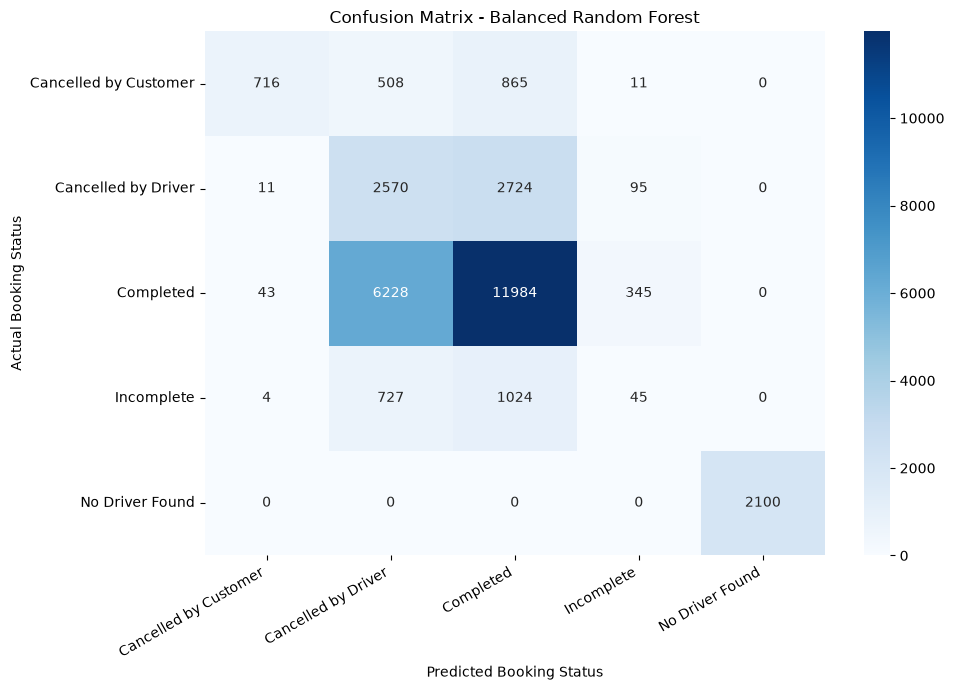

In [94]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=final_model.classes_
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=final_model.classes_,
    yticklabels=final_model.classes_
)

plt.title('Confusion Matrix - Balanced Random Forest')
plt.xlabel('Predicted Booking Status')
plt.ylabel('Actual Booking Status')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 18.2 Confusion Matrix Interpretation

The confusion matrix provides additional insight into the prediction errors of the final Balanced Random Forest model.

The major source of misclassification is between **Completed** and **Cancelled by Driver** bookings. A substantial number of actual completed rides are predicted as driver cancellations, while some driver cancellations are predicted as completed rides.

The model also has difficulty identifying **Incomplete** bookings. Many actual incomplete rides are classified as either completed or cancelled by driver, which is consistent with the very low recall of the `Incomplete` class.

In contrast, **No Driver Found** bookings are correctly identified, with all observations classified correctly. This is strongly influenced by the `VTAT_Missing` feature, which is perfectly associated with this booking outcome in the dataset.

Overall, the confusion matrix confirms that the model is better at identifying some operational outcomes than others and that minority-class prediction remains the main challenge.


### 18.3 Final Evaluation Summary

The final **Balanced Random Forest** model was evaluated on **30,000 unseen test records**.

| Metric            |     Result |
| ----------------- | ---------: |
| Accuracy          | **58.05%** |
| Macro F1-score    | **0.5103** |
| Balanced Accuracy | **49.72%** |

The model achieves a Macro F1-score of **0.5103**, making it the strongest practical model among the six evaluated models.

The results also show that the model performs substantially better for `Completed` and `No Driver Found` bookings than for `Incomplete` and `Cancelled by Driver` bookings.

Therefore, the model should be considered a useful analytical and operational-stage prediction model rather than a highly accurate standalone booking-outcome prediction system.


# 19. Feature Importance

Feature importance is used to identify which variables contribute most to the predictions of the final Balanced Random Forest model.

Understanding feature importance helps translate the machine learning results into meaningful business insights and provides greater interpretability of the model.


In [95]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

display(feature_importance.head(15))

,Feature,Importance
0,num__Avg VTAT,0.210945
1,num__VTAT_Missing,0.201264
2,num__Day,0.044301
3,num__Hour,0.039120
4,num__Month,0.037571
5,cat__Vehicle Type_Auto,0.009488
6,cat__Vehicle Type_Go Mini,0.008535
7,cat__Day_Period_Evening,0.007786
8,cat__Day_Period_Afternoon,0.007778
9,cat__Vehicle Type_Bike,0.007718


### 19.2 Feature Importance Interpretation

The feature importance analysis shows that **Avg VTAT** is the most influential feature in the final Balanced Random Forest model, contributing approximately **21.09%** of the total feature importance.

The `VTAT_Missing` indicator is the second most important feature, contributing approximately **20.13%**.

Together, these two features account for approximately **41.22%** of the model's total feature importance. This indicates that vehicle arrival-time information and its availability are highly influential in predicting booking outcomes.

Other important features include:

* **Day:** 4.43%
* **Hour:** 3.91%
* **Month:** 3.76%

Vehicle type, day period, weekend status, and day of week have smaller individual contributions.

The strong importance of `Avg VTAT` and `VTAT_Missing` confirms that the model is primarily capturing **operational-stage booking information** rather than purely pre-booking customer or ride characteristics.


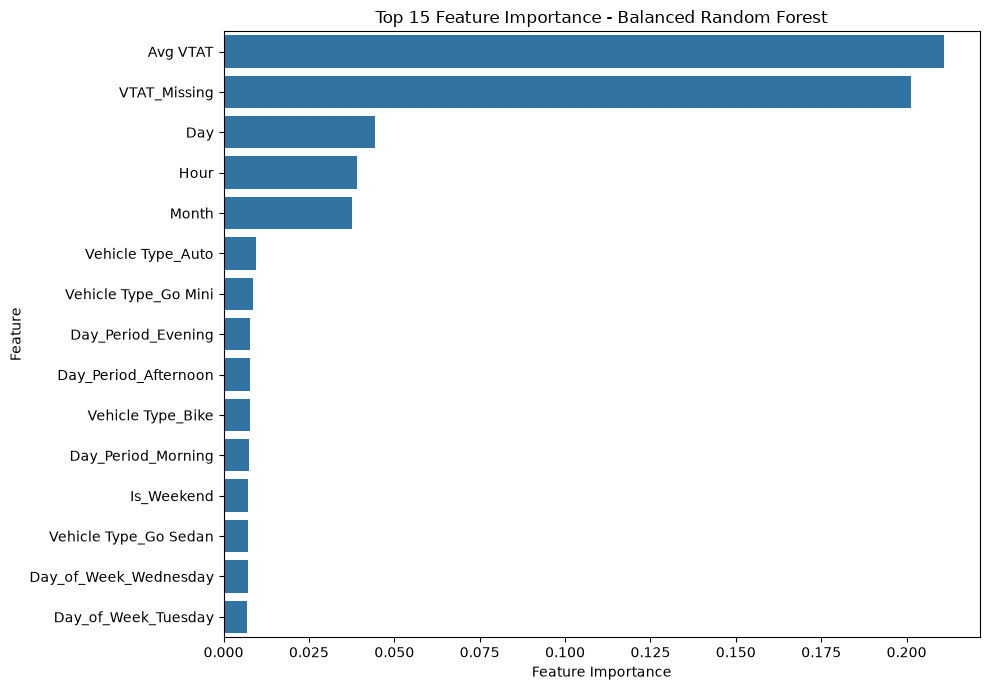

In [96]:
top_features = feature_importance.head(15).copy()

# Clean feature names for presentation
top_features['Feature'] = (
    top_features['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importance - Balanced Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 20. Business Insights

The analysis of 150,000 OLA booking records produced several operational and customer-experience insights.

### 1. Completed bookings are the majority outcome

Approximately **62% of bookings were completed**, while the remaining bookings resulted in driver cancellation, customer cancellation, no driver availability, or incomplete rides.

**Business implication:** Improving the conversion of unsuccessful bookings into completed rides could have a meaningful impact on customer experience and operational efficiency.

### 2. Driver cancellations are a significant source of unsuccessful bookings

Approximately **18% of all bookings were cancelled by drivers**, making driver cancellation the largest unsuccessful booking category.

The EDA showed that common driver cancellation reasons included customer-related issues, customer health-related concerns, and driver personal or vehicle-related issues.

**Business implication:** OLA could monitor driver cancellation patterns and investigate recurring causes by vehicle type, location, time period, and driver segment.

### 3. Customer cancellations require targeted intervention

Customer cancellations represented approximately **7% of bookings**.

The most common customer cancellation reasons included **Wrong Address**, **Change of Plans**, and **Driver Not Moving**.

**Business implication:** Better pickup-location accuracy, improved driver movement visibility, and clearer customer communication could potentially reduce avoidable customer cancellations.

### 4. No Driver Found is strongly associated with VTAT availability

The `Avg VTAT` missingness indicator perfectly identified the `No Driver Found` category in this dataset.

The final model achieved **100% recall and precision** for this class.

**Business implication:** Vehicle availability and dispatch-stage response time are important operational signals. Monitoring driver availability and reducing dispatch delays may help reduce bookings where no driver is found.

### 5. Peak booking activity occurs during evening hours

The highest hourly booking volume occurred around **6 PM**, with additional high activity during the evening period.

**Business implication:** Driver availability and fleet allocation can be monitored more closely during peak evening demand periods.

### 6. Temporal differences are relatively small

Completion rates across weekdays, weekends, and day periods were relatively similar.

For example, weekend completion was approximately **62.31%**, compared with approximately **61.88%** on weekdays.

**Business implication:** Booking outcomes appear to be influenced more by operational factors than by simple weekday/weekend segmentation.

### 7. VTAT-related features dominate the machine learning model

`Avg VTAT` and `VTAT_Missing` together contributed approximately **41.22%** of the model's total feature importance.

**Business implication:** Vehicle arrival-time information is highly valuable for operational-stage prediction and could be useful for monitoring dispatch performance.

However, this also means the model should not be interpreted as a pure pre-booking prediction model because VTAT information becomes available during the operational/dispatch process.

### 8. Incomplete bookings remain difficult to predict

The final model achieved only **0.04 F1-score** for the `Incomplete` class.

**Business implication:** Additional operational variables may be required to better identify and prevent incomplete rides. Future analysis could investigate the specific causes, timing, vehicle conditions, and customer behavior associated with incomplete bookings.


### 20.2 Executive Business Summary

The analysis indicates that OLA's booking outcomes are strongly influenced by operational factors, particularly vehicle arrival-time information and driver availability.

The largest unsuccessful outcome was **driver cancellation**, accounting for approximately 18% of bookings, while customer cancellations accounted for approximately 7%.

The machine learning analysis showed that `Avg VTAT` and `VTAT_Missing` were the two most important predictive features, together contributing approximately 41% of total feature importance.

The model successfully identifies `No Driver Found` bookings, but it struggles with `Incomplete` rides and some cancellation categories.

From a business perspective, the key opportunities are to improve driver availability during peak demand, investigate recurring driver and customer cancellation reasons, improve dispatch performance, and develop additional operational signals for identifying incomplete rides.


# 21. Limitations & Leakage Caveat

Although the final Balanced Random Forest provides useful predictive insights, several limitations should be considered when interpreting the results.

### 1. Operational-stage prediction

The final model includes `Avg VTAT` and `VTAT_Missing`.

These variables provide information about the operational/dispatch stage of a booking. Therefore, the model should **not** be interpreted as a pure pre-booking prediction model.

Instead, it represents an **operational-stage booking outcome prediction scenario**.

### 2. Strong dependency on VTAT-related features

`Avg VTAT` and `VTAT_Missing` together contribute approximately **41.22%** of the model's feature importance.

In particular, `VTAT_Missing` perfectly identifies the `No Driver Found` category in this dataset.

This creates a strong relationship between the feature and the target outcome.

### 3. Outcome-dependent variables were excluded

Several variables were deliberately excluded from the machine learning dataset because their availability depends on the booking outcome.

These included:

* `Avg CTAT`
* `Booking Value`
* `Ride Distance`
* `Payment Method`
* Customer cancellation fields
* Driver cancellation fields
* Incomplete ride fields
* Driver ratings
* Customer ratings

Including these variables could result in unrealistic or outcome-dependent predictions.

### 4. Class imbalance

The dataset contains five booking-status categories with a clear imbalance.

`Completed` bookings represent approximately **62%** of the dataset, while `Incomplete` bookings represent only approximately **6%**.

Although class weighting was used in the Balanced Random Forest, minority-class performance remains challenging.

### 5. Limited time variation

The dataset contains records from **2024**, so the `Year` feature has limited variation.

Therefore, the model's ability to generalize to substantially different years or changing operational conditions has not been established.

### 6. Model generalization

The model was evaluated using a random stratified train-test split.

Although this provides a reliable initial evaluation, a future production implementation should ideally use **time-based validation** and, where possible, data from a different time period to test whether the model generalizes to future bookings.

### 7. Dataset-specific findings

The analysis is based on the available dataset and its particular operational patterns.

The identified relationships should therefore be validated against real-world OLA operational data before being used for business decisions.

### Overall Limitation

The final model should be viewed as an **analytical and operational-stag**


# 22. Final Conclusion

This project analyzed **150,000 OLA ride-booking records** to understand booking outcomes and develop a machine learning model for predicting `Booking Status`.

The analysis began with data quality assessment and exploratory data analysis to identify booking patterns, cancellation behavior, temporal trends, and operational factors affecting ride outcomes.

Feature engineering was performed to create useful time-based variables including `Year`, `Month`, `Day`, `Hour`, `Day_of_Week`, `Day_Period`, and `Is_Weekend`.

A detailed missing-value and leakage analysis was then performed. Outcome-dependent and post-ride variables were excluded from the machine learning dataset, while `Avg VTAT` was retained as an operational-stage feature. A `VTAT_Missing` indicator was also created because its absence was strongly associated with the `No Driver Found` outcome.

Six machine learning approaches were evaluated:

* Baseline Random Forest
* Random Forest without VTAT
* Balanced Random Forest
* SGD Logistic Regression
* Tuned Balanced Random Forest
* XGBoost

Because the target variable was imbalanced, **Macro F1-score** was used as the primary model-selection metric.

The **Balanced Random Forest** was selected as the final model, achieving:

* **Accuracy:** 58.05%
* **Macro F1-score:** 0.5103
* **Balanced Accuracy:** 49.72%

The model achieved particularly strong performance for `No Driver Found` bookings and reasonable performance for `Completed` bookings, while `Incomplete` and `Cancelled by Driver` remained more difficult to predict.

Feature importance analysis showed that `Avg VTAT` and `VTAT_Missing` were the two most influential features, together contributing approximately **41.22%** of total feature importance.

From a business perspective, the analysis highlights the importance of driver availability, dispatch performance, cancellation monitoring, and peak-period fleet management.

Overall, this project demonstrates an end-to-end data analytics and machine learning workflow covering **data cleaning, exploratory analysis, feature engineering, leakage analysis, class-imbalance handling, model comparison, evaluation, interpretability, and business recommendations**.

The final model should be interpreted as an **operational-stage booking outcome prediction model**, rather than a pure pre-booking prediction system, due to its dependence on VTAT-related operational information.


# 23. Save ML Artifacts

The final machine learning model and supporting preprocessing objects are saved so that the project can be reproduced and the trained model can be reused without retraining from scratch.

The saved artifacts include the final Balanced Random Forest model, preprocessing pipeline, feature names, model comparison results, and final evaluation metrics.


In [97]:
import joblib
import json

# Save final model
joblib.dump(
    final_model,
    'ola_balanced_random_forest.pkl'
)

# Save preprocessing pipeline
joblib.dump(
    preprocessor,
    'ola_preprocessor.pkl'
)

# Save processed feature names
joblib.dump(
    feature_names,
    'ola_feature_names.pkl'
)

# Save model comparison
model_comparison.to_csv(
    'ola_model_comparison.csv',
    index=False
)

# Save final metrics
final_metrics = {
    'Model': 'Balanced Random Forest',
    'Accuracy': float(accuracy_score(y_test, final_predictions)),
    'Macro F1': float(f1_score(y_test, final_predictions, average='macro')),
    'Balanced Accuracy': float(
        balanced_accuracy_score(y_test, final_predictions)
    )
}

with open('ola_final_metrics.json', 'w') as file:
    json.dump(final_metrics, file, indent=4)

print("ML artifacts saved successfully.")

ML artifacts saved successfully.


In [98]:
import os
import joblib
import json

artifact_files = [
    'ola_balanced_random_forest.pkl',
    'ola_preprocessor.pkl',
    'ola_feature_names.pkl',
    'ola_model_comparison.csv',
    'ola_final_metrics.json'
]

print("Artifact Verification")
print("---------------------")

for file in artifact_files:
    print(f"{file}: {'Found' if os.path.exists(file) else 'Missing'}")

# Reload model and preprocessor
loaded_model = joblib.load('ola_balanced_random_forest.pkl')
loaded_preprocessor = joblib.load('ola_preprocessor.pkl')
loaded_feature_names = joblib.load('ola_feature_names.pkl')

with open('ola_final_metrics.json', 'r') as file:
    loaded_metrics = json.load(file)

print("\nLoaded Model:", type(loaded_model).__name__)
print("Loaded Preprocessor:", type(loaded_preprocessor).__name__)
print("Number of Feature Names:", len(loaded_feature_names))
print("Loaded Metrics:", loaded_metrics)

Artifact Verification
---------------------
ola_balanced_random_forest.pkl: Found
ola_preprocessor.pkl: Found
ola_feature_names.pkl: Found
ola_model_comparison.csv: Found
ola_final_metrics.json: Found

Loaded Model: RandomForestClassifier
Loaded Preprocessor: ColumnTransformer
Number of Feature Names: 377
Loaded Metrics: {'Model': 'Balanced Random Forest', 'Accuracy': 0.5805, 'Macro F1': 0.510295709664579, 'Balanced Accuracy': 0.4972358764294248}


In [99]:
# Generate predictions using the reloaded model
reloaded_predictions = loaded_model.predict(
    X_test_processed
)

# Check whether predictions are identical
predictions_match = np.array_equal(
    final_predictions,
    reloaded_predictions
)

print("Reloaded model verification")
print("---------------------------")
print("Predictions identical:", predictions_match)
print("Number of predictions:", len(reloaded_predictions))

Reloaded model verification
---------------------------
Predictions identical: True
Number of predictions: 30000
